# Машинное обучение, DS-поток
## Задание ML.7

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  120 баллов.
* Задача 2 &mdash;  120 баллов.

In [1]:
from IPython.display import Image
from typing import List, Optional, Tuple, Union
from typing import Callable
from graphviz import Digraph

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import Optimizer
from torch.utils.data import TensorDataset, DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from torchvision.datasets import MNIST

from tqdm.notebook import tqdm
from collections import defaultdict

N_JOBS = 2
RANDOM_STATE = 42

sns.set(style="darkgrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(device)

cuda:0


In [ ]:
# Bot check

# HW_ID: ds_ml7
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована




---
### Задача 1

Исследуем, как `batch_size`, `BatchNorm`, регуляризация и `Dropout` влияют на качество нейронной сети. В ходе исследования мы проверим теорию на практике, чтобы увидеть, как эти опции действительно работают.

Будем работать с хорошо знакомым нам датасетом MNIST.

In [2]:
img_size = 14  # будем работать с уменьшенными картинками

transform = transforms.Compose(
    [transforms.Resize((img_size, img_size)), transforms.ToTensor()]
)
train_set = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_set = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

print(f"\nTrain size: {len(train_set)}\nTest size:  {len(test_set)}")


Train size: 60000
Test size:  10000


Ради ускорения экспериментов ограничимся 10% датасета.

In [3]:
train_size = 6000
test_size = 1000


def get_subset(dataset: Dataset, size: int) -> Subset:
    """Выбираем случайное подмножество примеров из датасета.

    Args:
        dataset (Dataset): Исходный датасет, из которого будет выбрано подмножество.
        size (int): Количество примеров в подмножестве.

    Returns:
        Subset: Подмножество датасета (объект torch.utils.data.Subset).
    """
    indices = np.random.choice(np.arange(len(dataset)), size=size, replace=False)
    return Subset(dataset, indices)


train_subset = get_subset(train_set, train_size)
test_subset = get_subset(test_set, test_size)

print(f"\nTrain size new: {len(train_subset)}\nTest size new:  {len(test_subset)}")


Train size new: 6000
Test size new:  1000


Далеее по умолчанию для обучения и тестирования используйте `train_subset` и `test_subset` соответственно.

Для того, чтобы вы быстрее выполнили задание, предлагатся дописать и использовать следующие функции.

In [13]:
def accuracy(logits: torch.Tensor, target: torch.Tensor):
    """Оценка метрики точности для логитов и таргета.

    Args:
        logits (torch.Tensor): Логиты модели (сырые предсказания).
        target (torch.Tensor): Истинные метки.
    """
    return (logits.argmax(dim=1) == target).float().mean().item()

def evaluate(model: nn.Module, loader: DataLoader, device: torch.device, criterion: Callable):
    """Оценка лосса и точности для модели.

    Args:
        model (Module): Модель для оценки.
        loader (DataLoader): Загрузчик данных для валидации/теста.
        device (torch.device): Устройство (CPU/GPU), на котором выполняются вычисления.
        criterion (Callable): Функция потерь (лосс).
    """

    # Переводим модель в режим оценки (evaluation mode)
    model.eval()

    # Здесь будем считать общий лосса и точность
    total_loss = 0.0
    total_accuracy = 0.0
    total_size = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Получаем предсказания модели и считаем лосс
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            # Считаем точность для текущего батча
            batch_accuracy = accuracy(logits, y_batch)

            # Накапливаем лосс и точность с учетом размера батча
            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_accuracy += batch_accuracy * batch_size
            total_size += batch_size

    # Считаем средние значения лосса и точности по всей выборке
    avg_loss = total_loss / total_size
    avg_accuracy = total_accuracy / total_size
    return avg_loss, avg_accuracy


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optimizer,
    device: torch.device,
    criterion: Callable,
):
    """Одна эпоха обучения.

    Args:
        model (Module): Модель для обучения.
        loader (DataLoader): Загрузчик данных для обучения.
        optimizer (Optimizer): Оптимизатор для обновления весов модели.
        device (torch.device): Устройство (CPU/GPU), на котором выполняются вычисления.
        criterion (Callable): Функция потерь (лосс).
    """

    # Переводим модель в режим обучения (training mode)
    model.train()

    # Здесь будем считать общий лосса и точность за эпоху
    running_loss = 0.0
    running_accuracy = 0.0
    total_size = 0

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        # Шаг обучения, при затруднениях посмотри в ноутбуки с занятия
        optimizer.zero_grad()
        out = model(x_batch)

        # Вычисляем функцию потерь
        loss = criterion(out, y_batch)
        loss.backward()

        optimizer.step()

        # Считаем точность для текущего батча
        batch_accuracy = accuracy(out, y_batch)

        # Накапливаем лосс и точность с учетом размера батча
        batch_size = x_batch.size(0)
        running_loss += loss.item() * batch_size
        running_accuracy += batch_accuracy * batch_size
        total_size += batch_size

    # Считаем средние значения лосса и точности по всей эпохе
    epoch_loss = running_loss / total_size
    epoch_accuracy = running_accuracy / total_size
    return epoch_loss, epoch_accuracy

**Общие указания для дальнейших экспериментов**


Рекомендуемые параметры

* Архитектура сети: Двухслойная нейронная сеть с функцией активации `ReLU`.
* Продолжительность обучения: 6 эпох. Этого должно быть достаточно для достижения приемлемых результатов.
* Оптимизатор: SGD с шагом обучения `lr = 0.1`.

Сравнение моделей проводите по следующим метрикам:
* Среднее время обучения, затраченное на одну эпоху.
* Функция потерь на трейне и тесте.
* Точность на трейне и тесте.

Для корректного сравнения стройте также графики зависимости метрики от количества эпох для каждого эксперимента.

**1.** Обучите модель последовательно со следующими размерами батчей: 1, 8, 32, 64, 128, `len(train)`. Сравните метрики на трейне и тесте.

In [5]:
num_epochs = 50
lr = 0.1
batch_sizes = [1, 8, 32, 64, 128]
history = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

def create_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(14 * 14, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )

for batch_size in tqdm(batch_sizes, desc="batch_sizes"):
    model = create_model().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(num_epochs), desc=f"bs={batch_size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history[batch_size]['loss']['train'].append(epoch_loss)
        history[batch_size]['acc']['train'].append(epoch_accuracy)
        history[batch_size]['loss']['test'].append(avg_loss)
        history[batch_size]['acc']['test'].append(avg_accuracy)

batch_sizes:   0%|          | 0/5 [00:00<?, ?it/s]

bs=1:   0%|          | 0/50 [00:00<?, ?it/s]

bs=8:   0%|          | 0/50 [00:00<?, ?it/s]

bs=32:   0%|          | 0/50 [00:00<?, ?it/s]

bs=64:   0%|          | 0/50 [00:00<?, ?it/s]

bs=128:   0%|          | 0/50 [00:00<?, ?it/s]

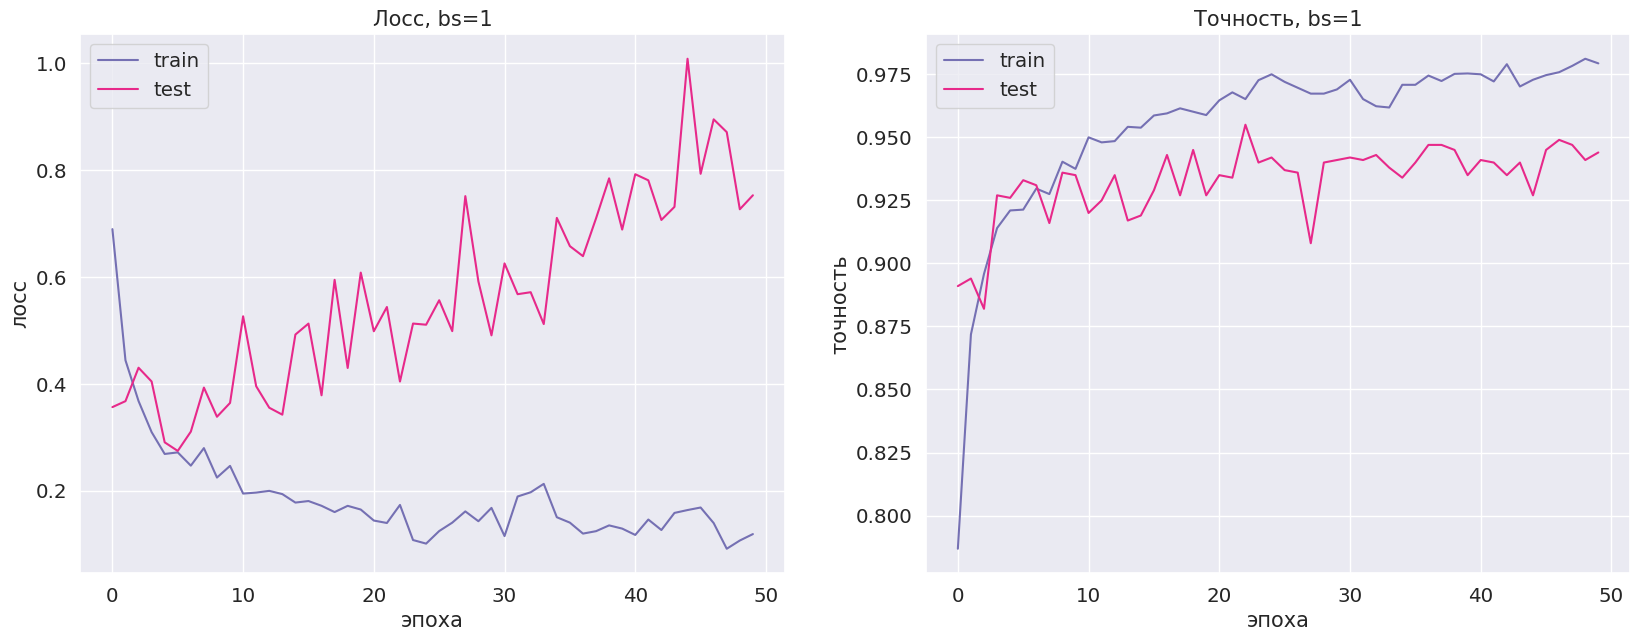

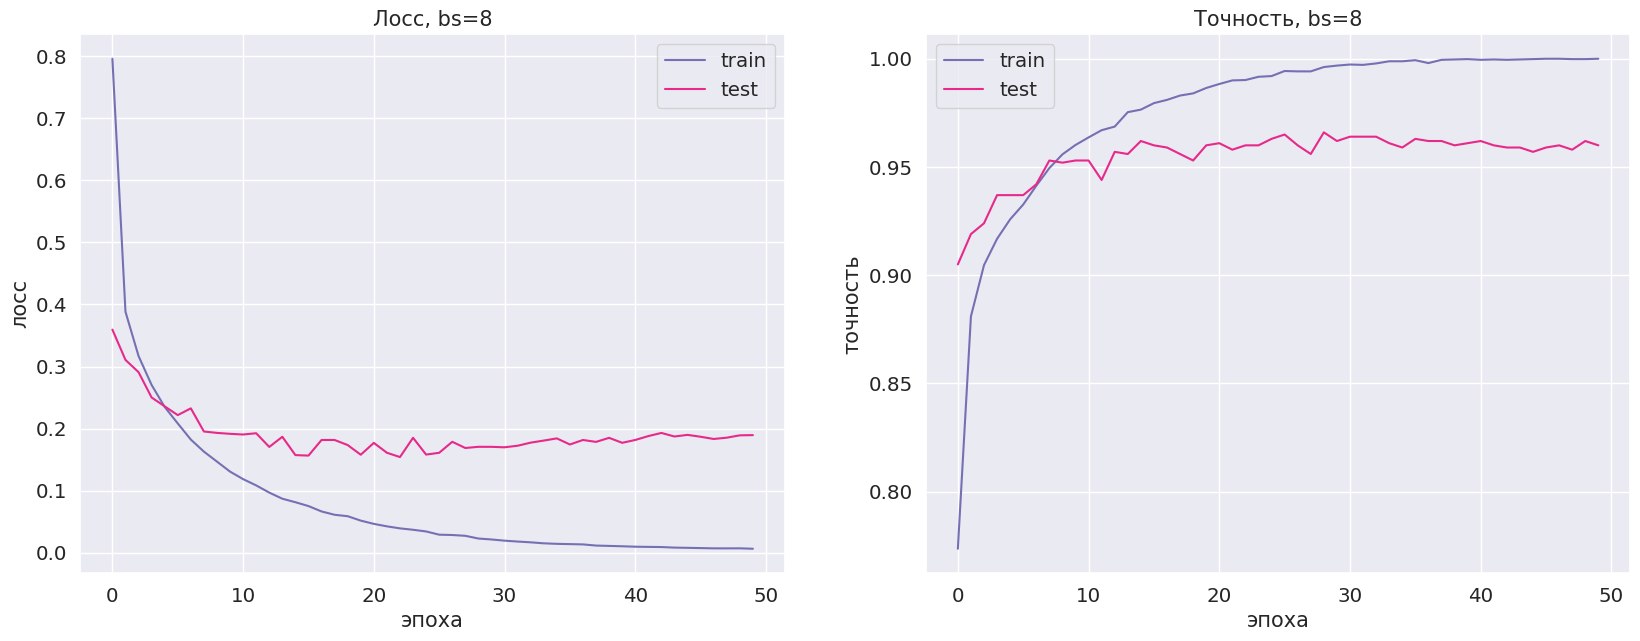

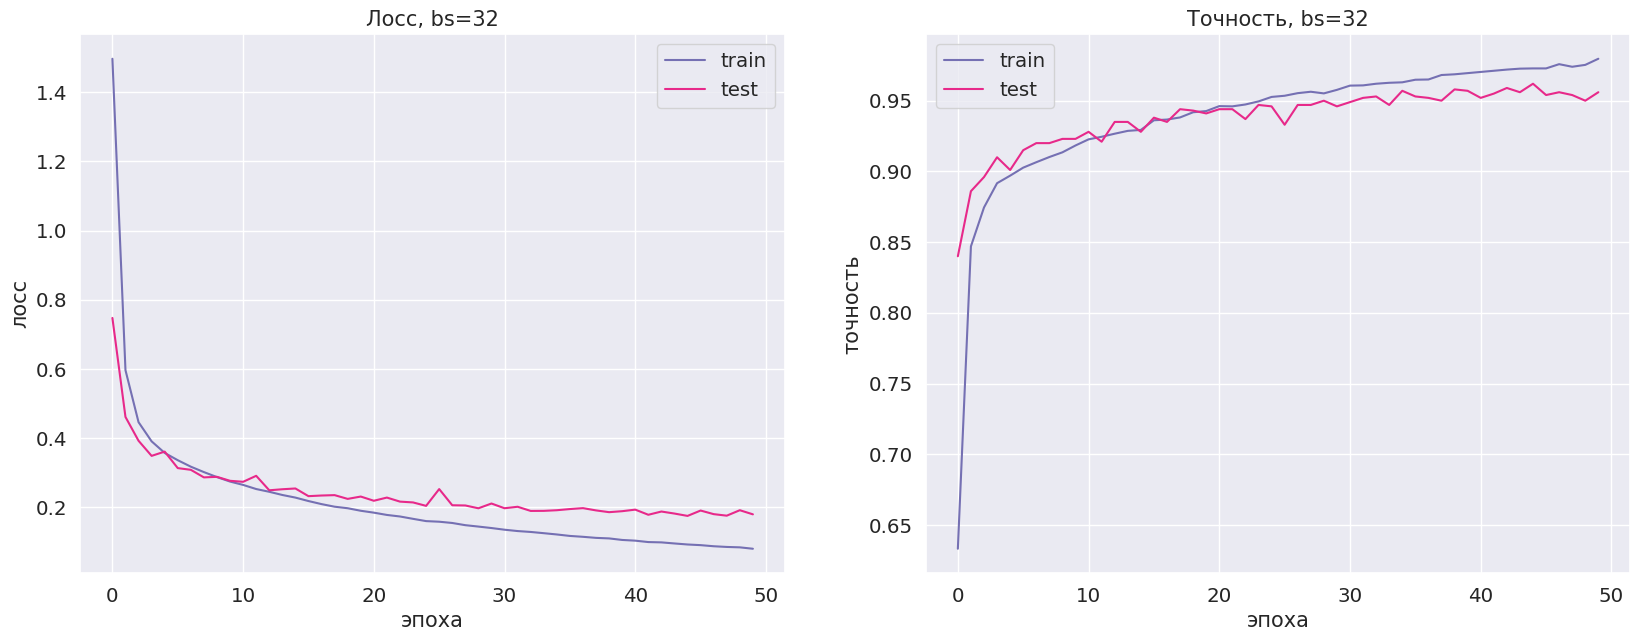

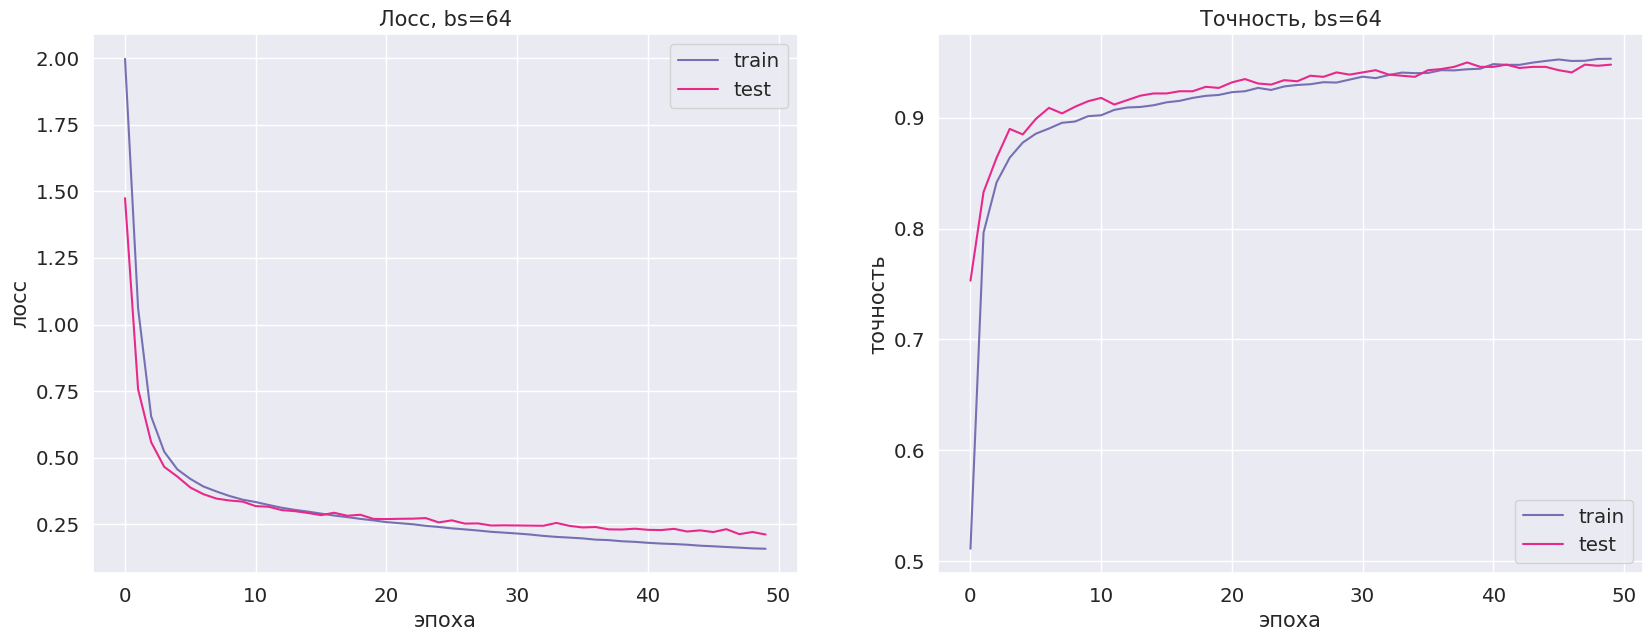

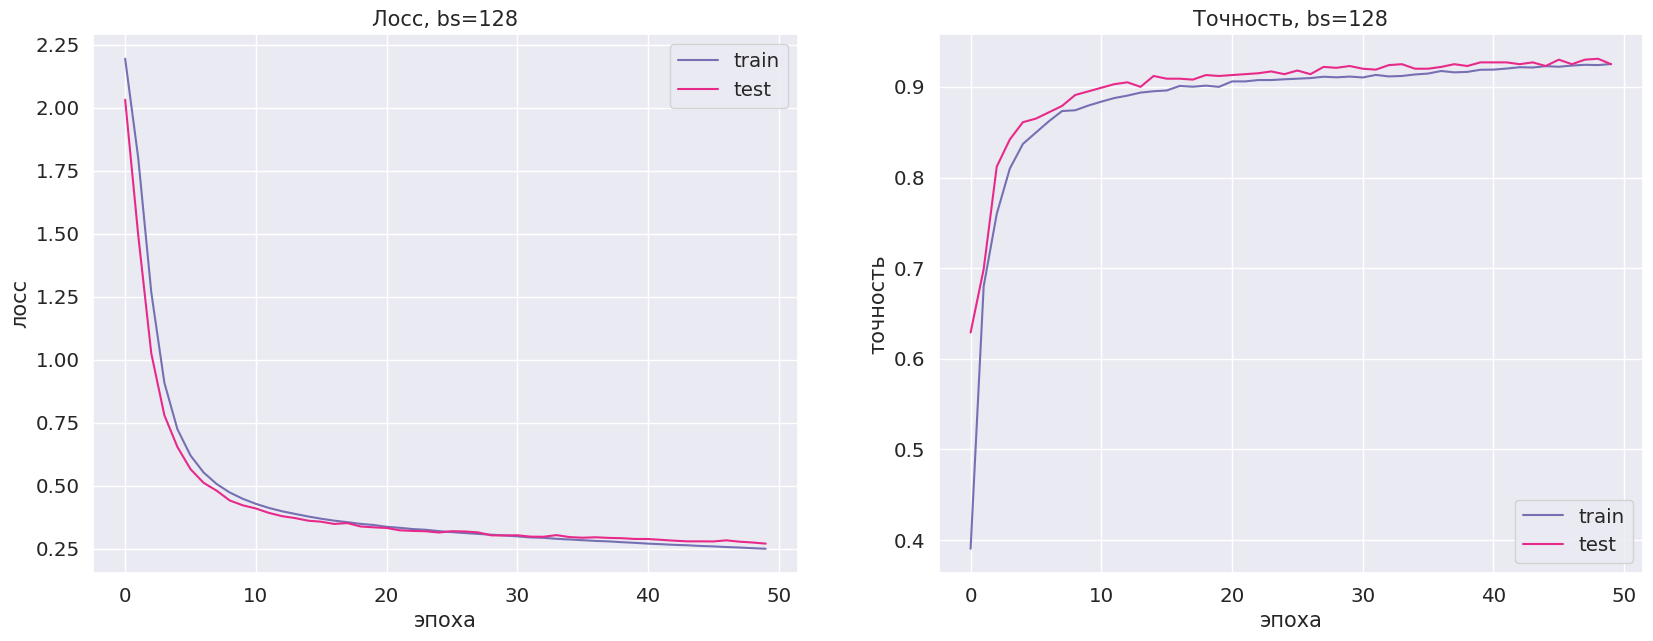

In [7]:
for batch_size in batch_sizes:
    fig = plt.figure(figsize=(20, 7))

    plt.subplot(1,2,1)
    plt.title(f'Лосс, bs={batch_size}', fontsize=15)
    plt.plot(history[batch_size]['loss']['train'], label='train')
    plt.plot(history[batch_size]['loss']['test'], label='test')
    plt.ylabel('лосс', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title(f'Точность, bs={batch_size}', fontsize=15)
    plt.plot(history[batch_size]['acc']['train'], label='train')
    plt.plot(history[batch_size]['acc']['test'], label='test')
    plt.ylabel('точность', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()
    plt.show()

Сделайте выводы об влиянии размера батча на скорость и результат обучения модели.

**Выводы:** Модель дольше учится при малом batch_size, потому что для полного обучения требуется перебрать больше строк в отдельности, обращаться к GPU/CPU, больше вычислять градиенты. При маленьком размере обучающей выборки почти сразу наступает переобучение, результаты очень шумные, потому что train происходит, возможно, на сильно отличающиихся данных от среднего. При большом размере видим, что, например, для размера 128, мы недоучились, значит нужно больше эпох обучения. Изменение accuracy и лосса менее шумное.


**2.** Для батчей размеров 8, 32, 64 проведите эксперименты с обучением в следующих режимах:
* без `BatchNorm`,
* `BatchNorm` до функции активации,
* `BatchNorm` после функции активации.

Сравните метрики на трейне и тесте.

In [162]:
def create_model_bn_before():
  return nn.Sequential(
      nn.Flatten(),
      nn.Linear(14 * 14, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Linear(64, 10)
  )

def create_model_bn_after():
  return nn.Sequential(
      nn.Flatten(),
      nn.Linear(14 * 14, 64),
      nn.ReLU(),
      nn.BatchNorm1d(64),
      nn.Linear(64, 10)
  )

In [9]:
num_epochs = 50
lr = 0.1
batch_sizes = [8, 32, 64]
history_bn_before = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
history_bn_after = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for batch_size in tqdm(batch_sizes, desc="batch_sizes"):
    model_bn_before = create_model_bn_before().to(device)
    optimizer = torch.optim.SGD(model_bn_before.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(num_epochs), desc=f"bs={batch_size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model_bn_before,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model_bn_before,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history_bn_before[batch_size]['loss']['train'].append(epoch_loss)
        history_bn_before[batch_size]['acc']['train'].append(epoch_accuracy)
        history_bn_before[batch_size]['loss']['test'].append(avg_loss)
        history_bn_before[batch_size]['acc']['test'].append(avg_accuracy)

batch_sizes:   0%|          | 0/3 [00:00<?, ?it/s]

bs=8:   0%|          | 0/50 [00:00<?, ?it/s]

bs=32:   0%|          | 0/50 [00:00<?, ?it/s]

bs=64:   0%|          | 0/50 [00:00<?, ?it/s]

In [11]:
for batch_size in tqdm(batch_sizes, desc="batch_sizes"):
    model_bn_after = create_model_bn_after().to(device)
    optimizer = torch.optim.SGD(model_bn_after.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(num_epochs), desc=f"bs={batch_size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model_bn_after,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model_bn_after,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history_bn_after[batch_size]['loss']['train'].append(epoch_loss)
        history_bn_after[batch_size]['acc']['train'].append(epoch_accuracy)
        history_bn_after[batch_size]['loss']['test'].append(avg_loss)
        history_bn_after[batch_size]['acc']['test'].append(avg_accuracy)

batch_sizes:   0%|          | 0/3 [00:00<?, ?it/s]

bs=8:   0%|          | 0/50 [00:00<?, ?it/s]

bs=32:   0%|          | 0/50 [00:00<?, ?it/s]

bs=64:   0%|          | 0/50 [00:00<?, ?it/s]

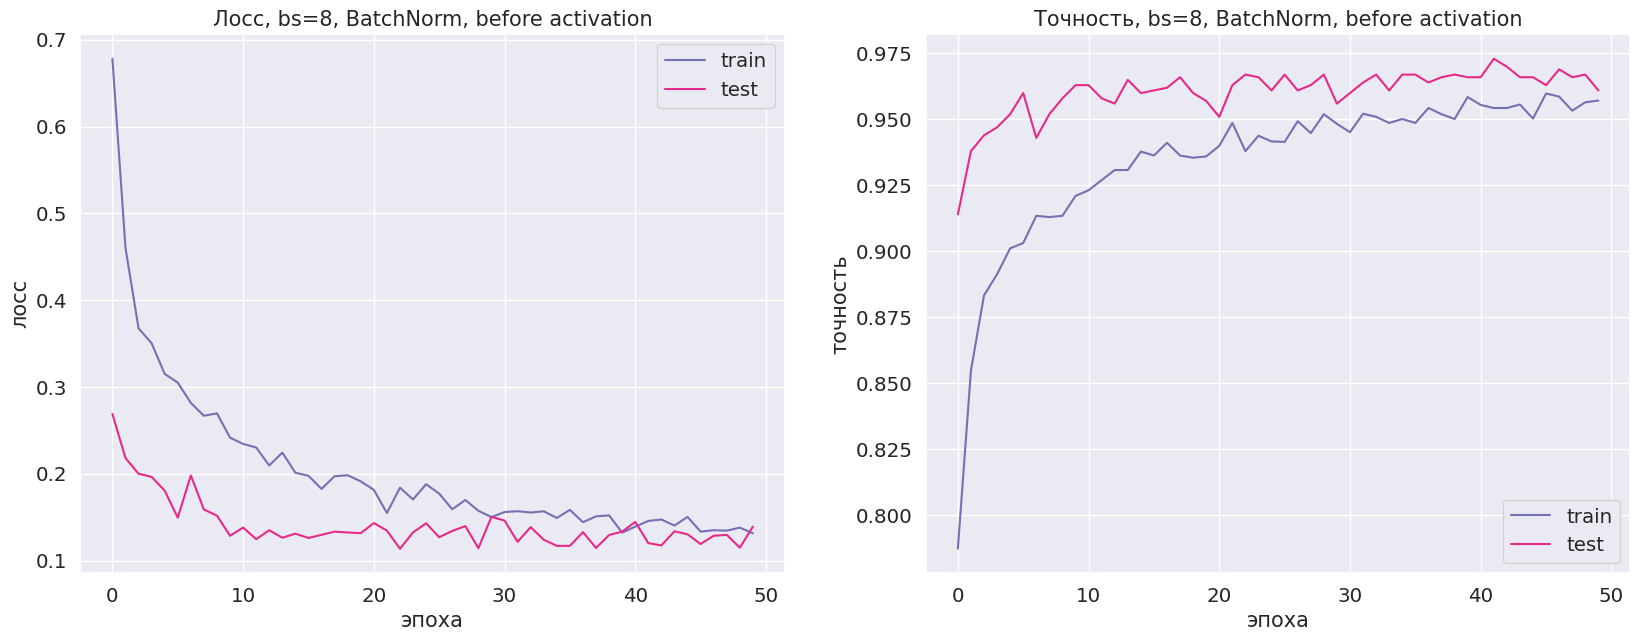

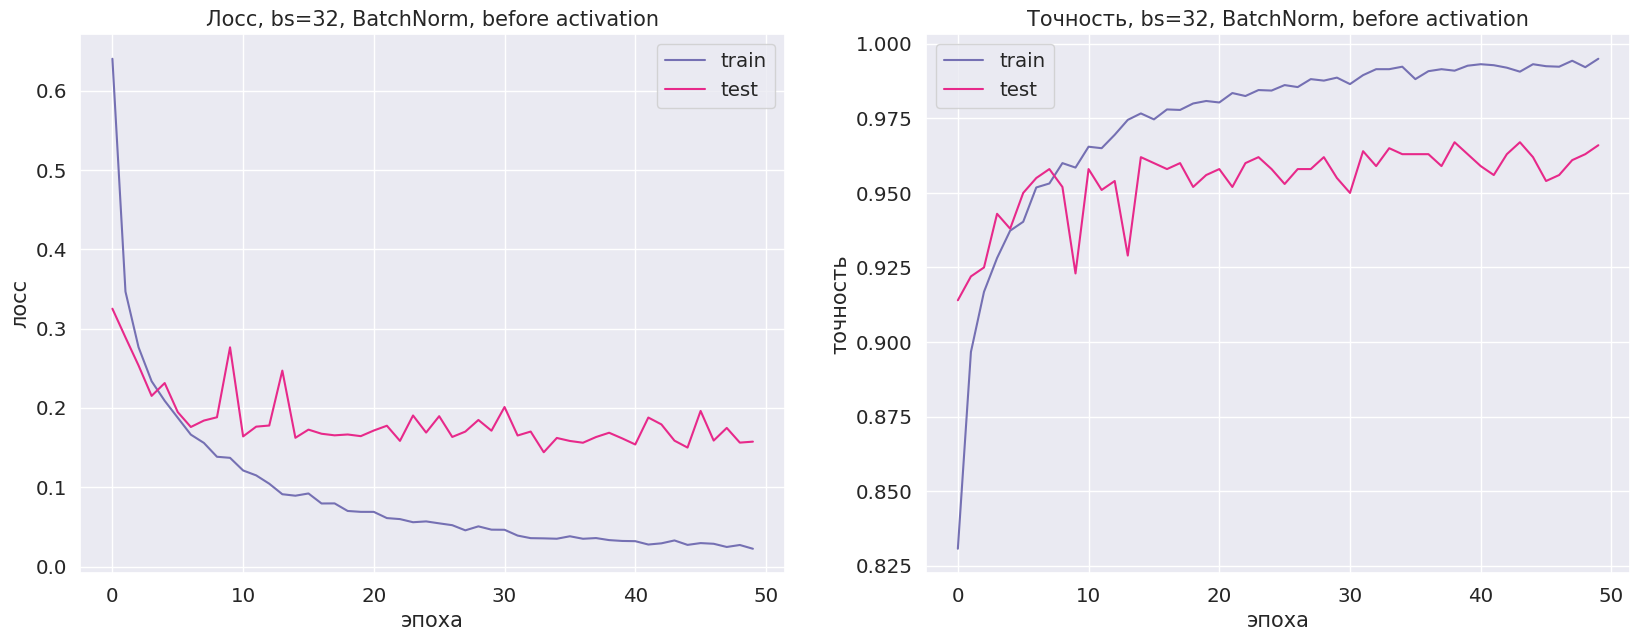

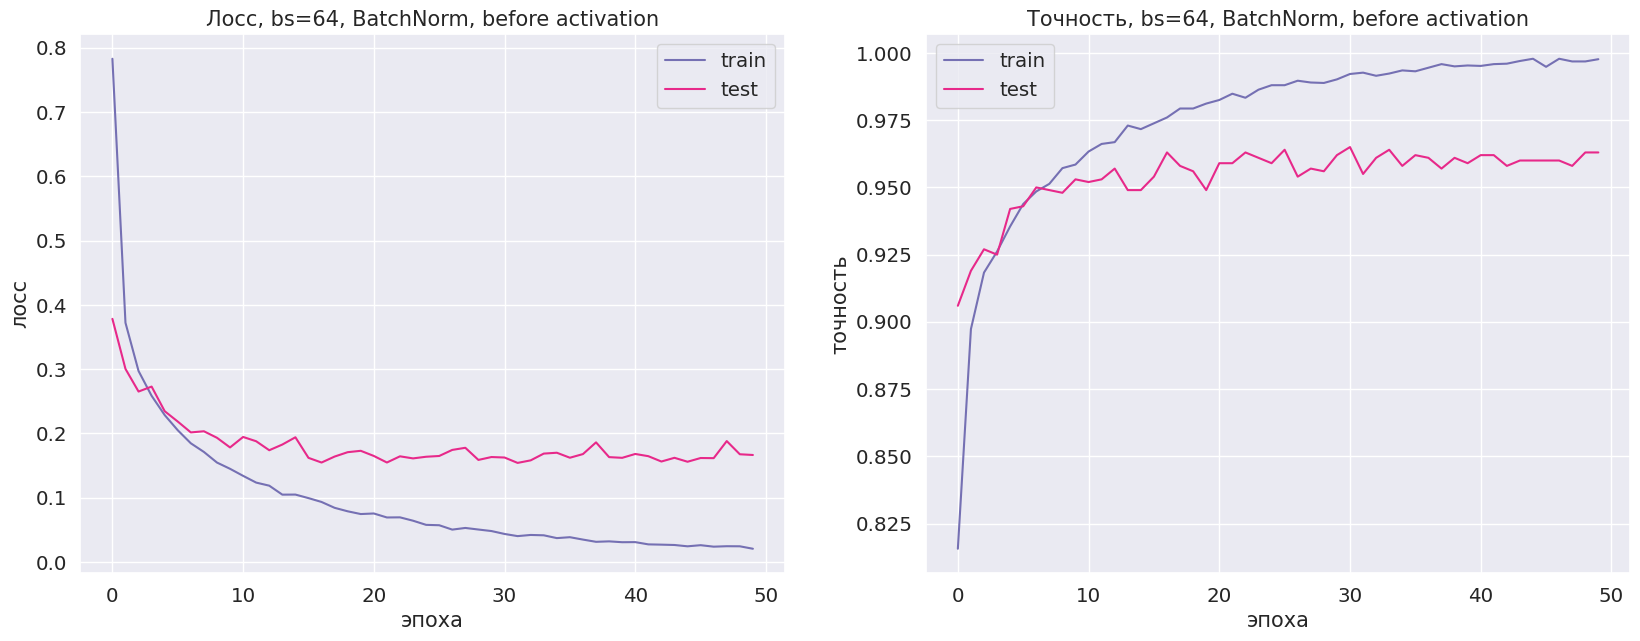

In [10]:
for batch_size in batch_sizes:
    fig = plt.figure(figsize=(20, 7))

    plt.subplot(1,2,1)
    plt.title(f'Лосс, bs={batch_size}, BatchNorm, before activation', fontsize=15)
    plt.plot(history_bn_before[batch_size]['loss']['train'], label='train')
    plt.plot(history_bn_before[batch_size]['loss']['test'], label='test')
    plt.ylabel('лосс', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title(f'Точность, bs={batch_size}, BatchNorm, before activation', fontsize=15)
    plt.plot(history_bn_before[batch_size]['acc']['train'], label='train')
    plt.plot(history_bn_before[batch_size]['acc']['test'], label='test')
    plt.ylabel('точность', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()
    plt.show()

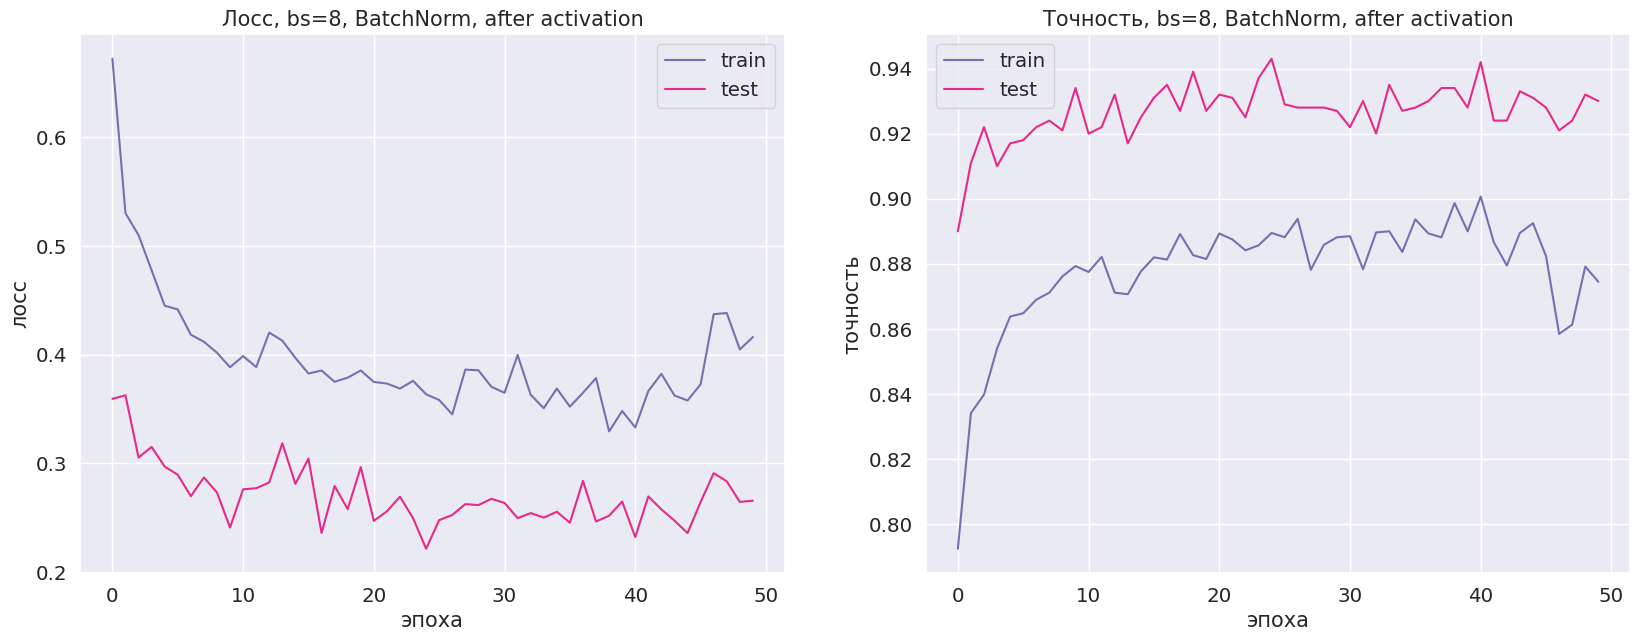

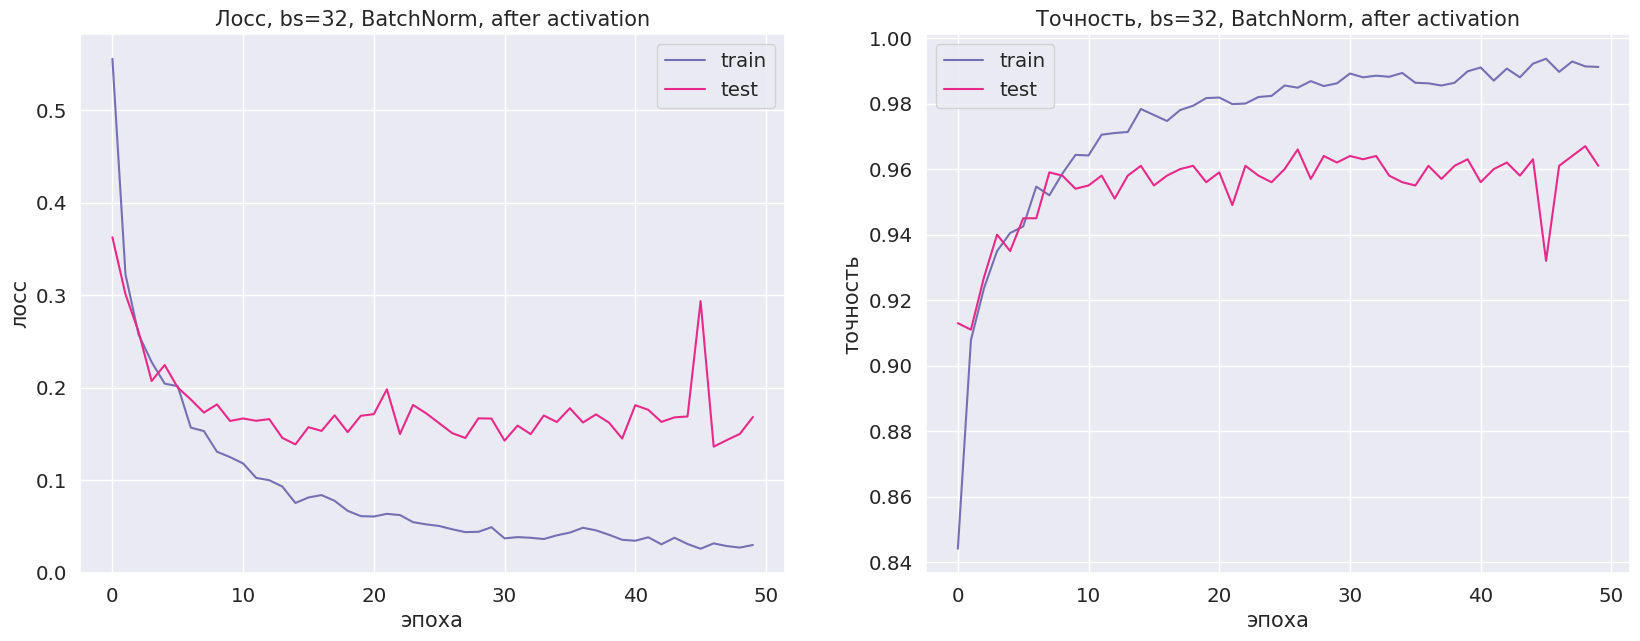

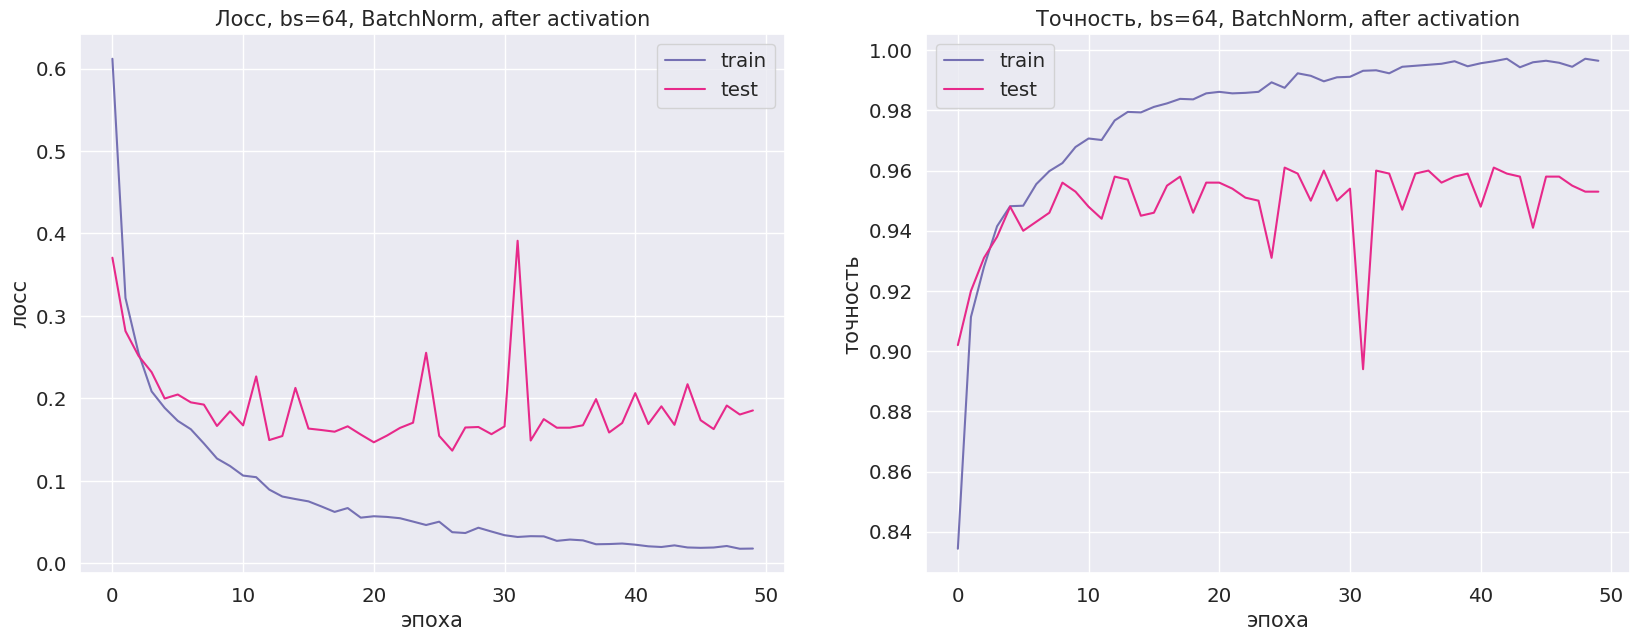

In [12]:
for batch_size in batch_sizes:
    fig = plt.figure(figsize=(20, 7))

    plt.subplot(1,2,1)
    plt.title(f'Лосс, bs={batch_size}, BatchNorm, after activation', fontsize=15)
    plt.plot(history_bn_after[batch_size]['loss']['train'], label='train')
    plt.plot(history_bn_after[batch_size]['loss']['test'], label='test')
    plt.ylabel('лосс', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title(f'Точность, bs={batch_size}, BatchNorm, after activation', fontsize=15)
    plt.plot(history_bn_after[batch_size]['acc']['train'], label='train')
    plt.plot(history_bn_after[batch_size]['acc']['test'], label='test')
    plt.ylabel('точность', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()
    plt.show()

Сильнее всего BatchNorm должен влиять в случае batch_size = 8. Видим, что при размещении этого типа нормализайии до функции активации результаты сильно лучше, чем прир размещении после. Это объясняется тем, что после применения ReLU часть данных меняется на ноль, выборочные статистики смещаются. В целом результаты лучше, чем без этого слоя, но не намного. Переобучение всё равно наступает, но на большей эпохе. Также результаты сильно более шумные, чем без регуляризации, присутствуют значительные выборсы

Постройте KDE-оценку распределения выхода активации линейного слоя для каждой из моделей.

Возьмём из уже написанного кода последний выход рассматриваемых моделей

In [156]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optimizer,
    device: torch.device,
    criterion: Callable,
):
    model.train()

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
    return out.to('cpu').detach().numpy()

In [159]:
outs_act = train_one_epoch(model=create_model().to(device),
                loader=train_loader,
                optimizer=optimizer,
                device=device,
                criterion=criterion)
outs_act_bn_before = train_one_epoch(model=create_model_bn_before().to(device),
                loader=train_loader,
                optimizer=optimizer,
                device=device,
                criterion=criterion)
outs_act_bn_after = train_one_epoch(model=create_model_bn_after().to(device),
                loader=train_loader,
                optimizer=optimizer,
                device=device,
                criterion=criterion)

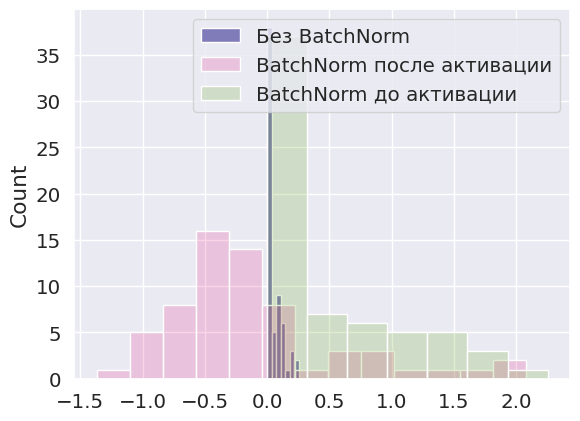

In [161]:
sns.histplot(outs_act[0, :], label='Без BatchNorm', alpha=0.9)
sns.histplot(outs_act_bn_after[0, :], label='BatchNorm после активации', alpha=0.2)
sns.histplot(outs_act_bn_before[0, :], label='BatchNorm до активации', alpha=0.2)
plt.legend()
plt.show()

Сделайте выводы об эффективности `BatchNorm`, а также о правильном порядке расположения `BatchNorm` и функции активации.

**Выводы:** Видим, что если BatchNorm фигурирует после ReLU, то появляются отрицательные значения предсказаний, что мешает, поэтому правильно ставить BatchNorm до ReLU

**3.** Добьемся переобучения модели. Для этого сильно уменьшим обучающую выборку. Для обучающей выборки размера 300, 600, 1200 примеров проведите эксперименты в следующих режимах:
* без `Dropout` и регуляризации,
* только с L2-регуляризацией (установите параметр `weight_decay` в оптимизаторе),
* только с `Dropout`,
* c `Dropout` и регуляризацией.

Сравните метрики на трейне и тесте.

In [9]:
def create_model():
  return nn.Sequential(
    nn.Flatten(),
    nn.Linear(14 * 14, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
)

def create_model_do():
  return nn.Sequential(
    nn.Flatten(),
    nn.Linear(14 * 14, 64),
    nn.Dropout(p=0.4),
    nn.ReLU(),
    nn.Linear(64, 10),
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
optimizer_reg = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=0.1)
optimizer_do = torch.optim.SGD(model_do.parameters(), lr=0.1)
optimizer_reg_do = torch.optim.SGD(model_do.parameters(), lr=0.1, weight_decay=0.1)

In [14]:
train_sizes = [300, 600, 1200]
batch_size = 32
epochs = 50
history = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for size in tqdm(train_sizes, desc=f'size'):
    model = create_model().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_subset = get_subset(train_set, size)
    test_subset = get_subset(test_set, size // 2)

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(epochs), desc=f"size={size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history[size]['loss']['train'].append(epoch_loss)
        history[size]['acc']['train'].append(epoch_accuracy)
        history[size]['loss']['test'].append(avg_loss)
        history[size]['acc']['test'].append(avg_accuracy)



size:   0%|          | 0/3 [00:00<?, ?it/s]

size=300:   0%|          | 0/50 [00:00<?, ?it/s]

size=600:   0%|          | 0/50 [00:00<?, ?it/s]

size=1200:   0%|          | 0/50 [00:00<?, ?it/s]

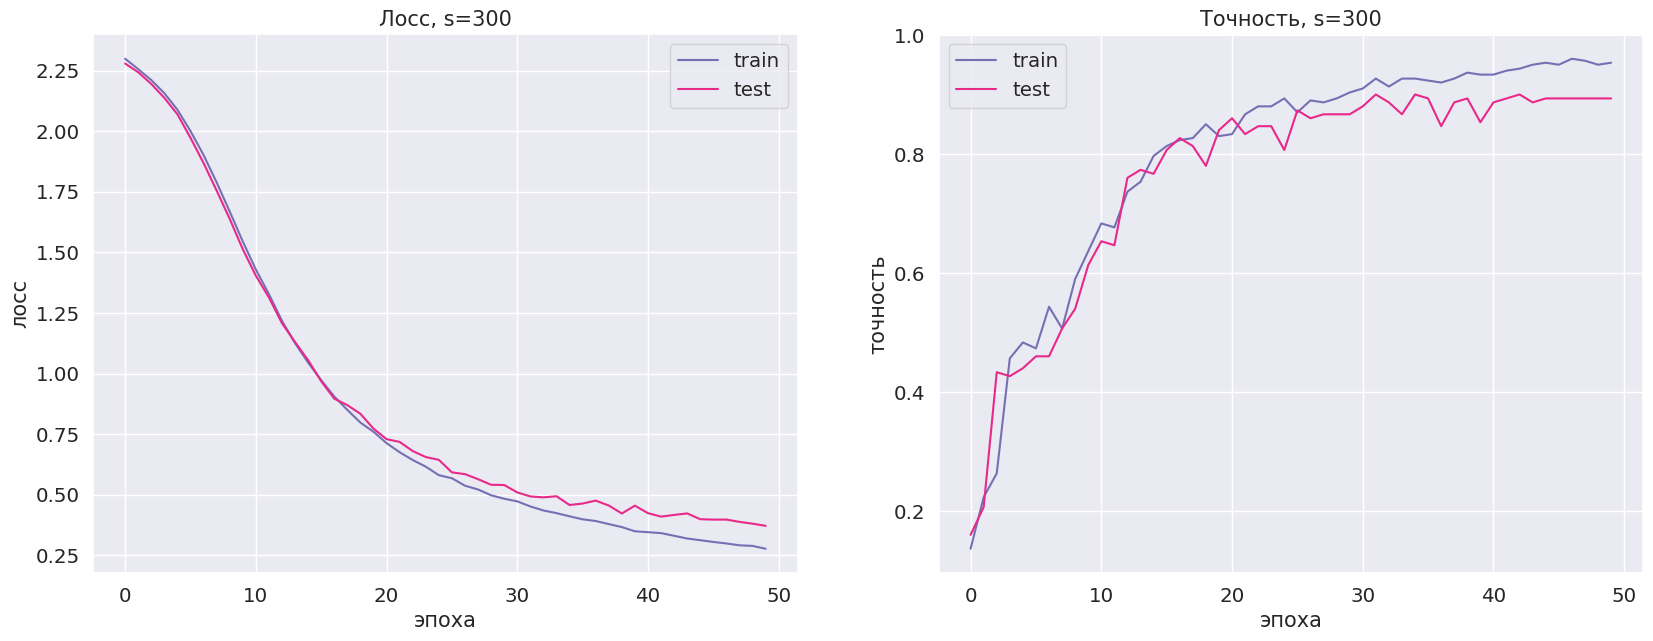

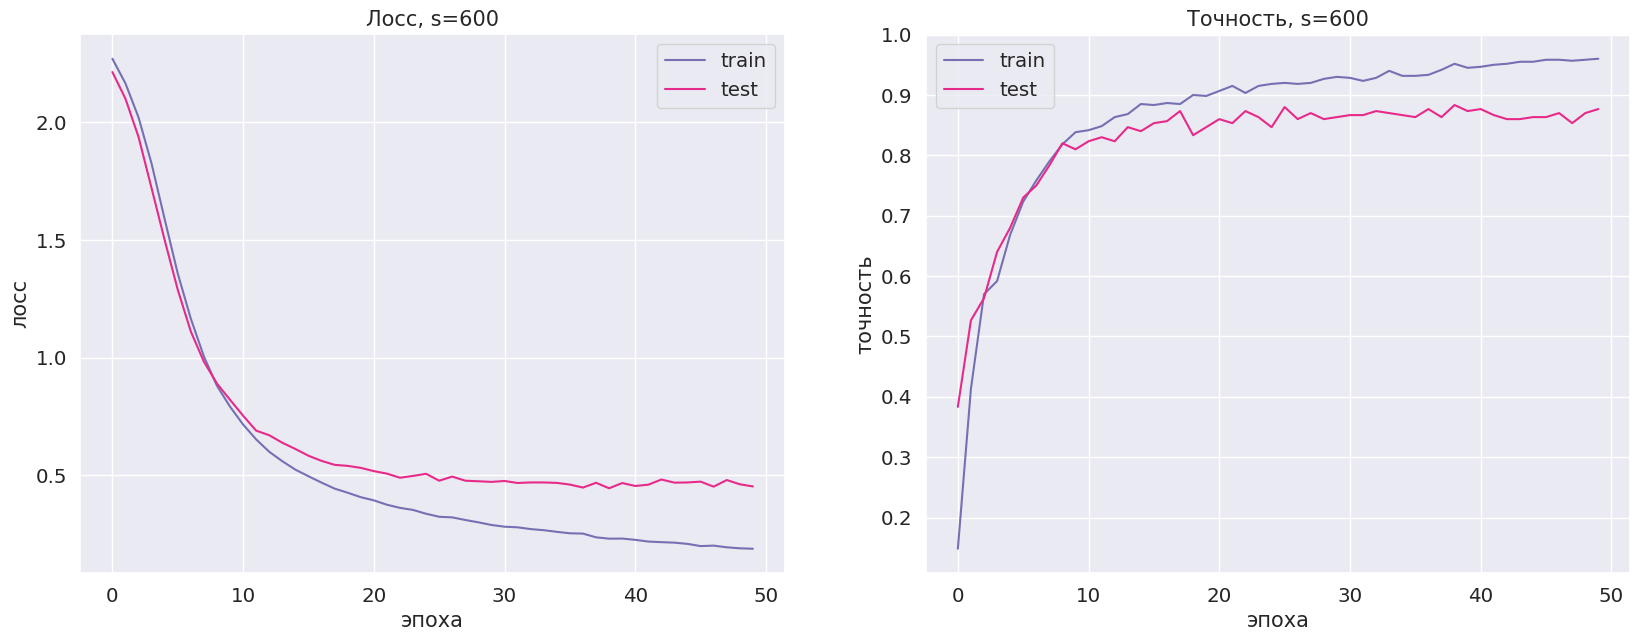

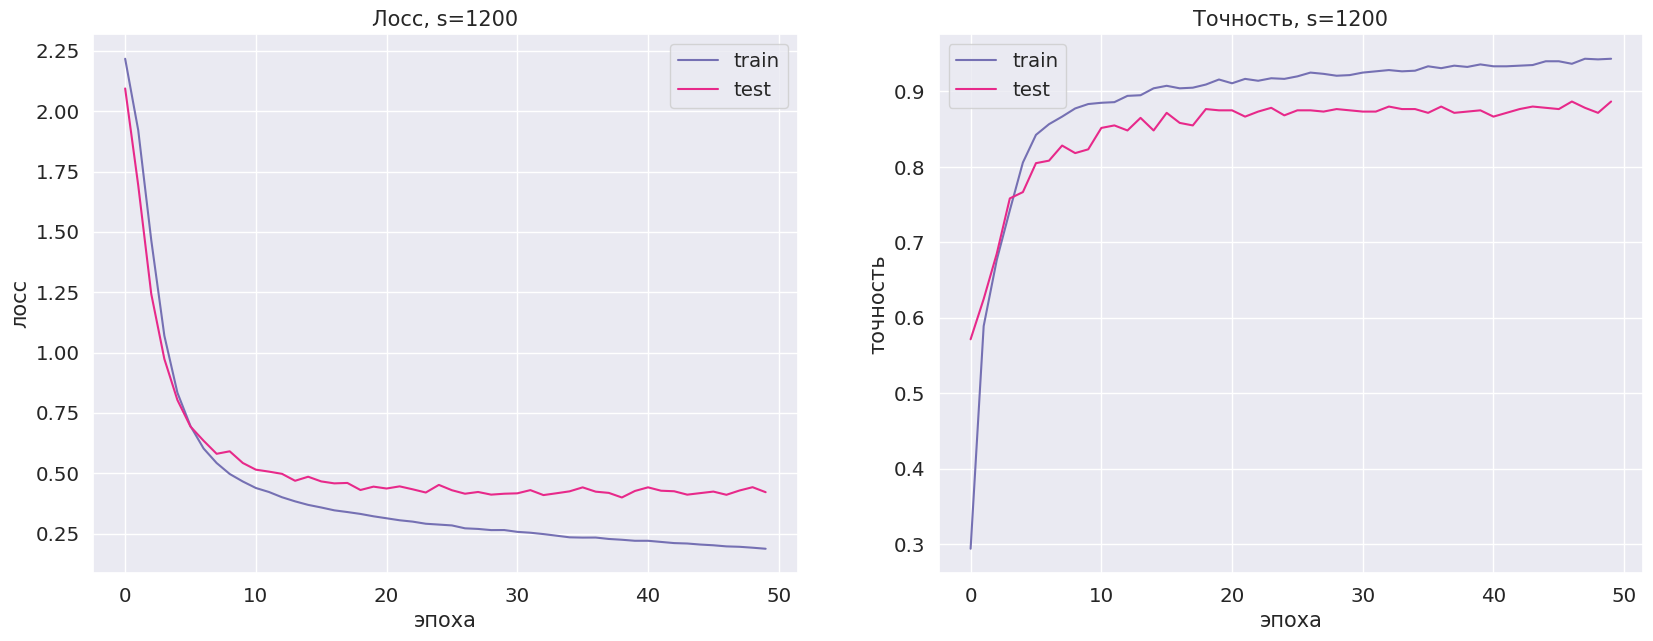

In [16]:
for size in train_sizes:
  fig = plt.figure(figsize=(20, 7))

  plt.subplot(1,2,1)
  plt.title(f'Лосс, s={size}', fontsize=15)
  plt.plot(history[size]['loss']['train'], label='train')
  plt.plot(history[size]['loss']['test'], label='test')
  plt.ylabel('лосс', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()

  plt.subplot(1,2,2)
  plt.title(f'Точность, s={size}', fontsize=15)
  plt.plot(history[size]['acc']['train'], label='train')
  plt.plot(history[size]['acc']['test'], label='test')
  plt.ylabel('точность', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()
  plt.show()

In [17]:
train_sizes = [300, 600, 1200]
batch_size = 32
epochs = 50
history = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for size in tqdm(train_sizes, desc=f'size'):
    model = create_model().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=0.1)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_subset = get_subset(train_set, size)
    test_subset = get_subset(test_set, size // 2)

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(epochs), desc=f"size={size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history[size]['loss']['train'].append(epoch_loss)
        history[size]['acc']['train'].append(epoch_accuracy)
        history[size]['loss']['test'].append(avg_loss)
        history[size]['acc']['test'].append(avg_accuracy)

size:   0%|          | 0/3 [00:00<?, ?it/s]

size=300:   0%|          | 0/50 [00:00<?, ?it/s]

size=600:   0%|          | 0/50 [00:00<?, ?it/s]

size=1200:   0%|          | 0/50 [00:00<?, ?it/s]

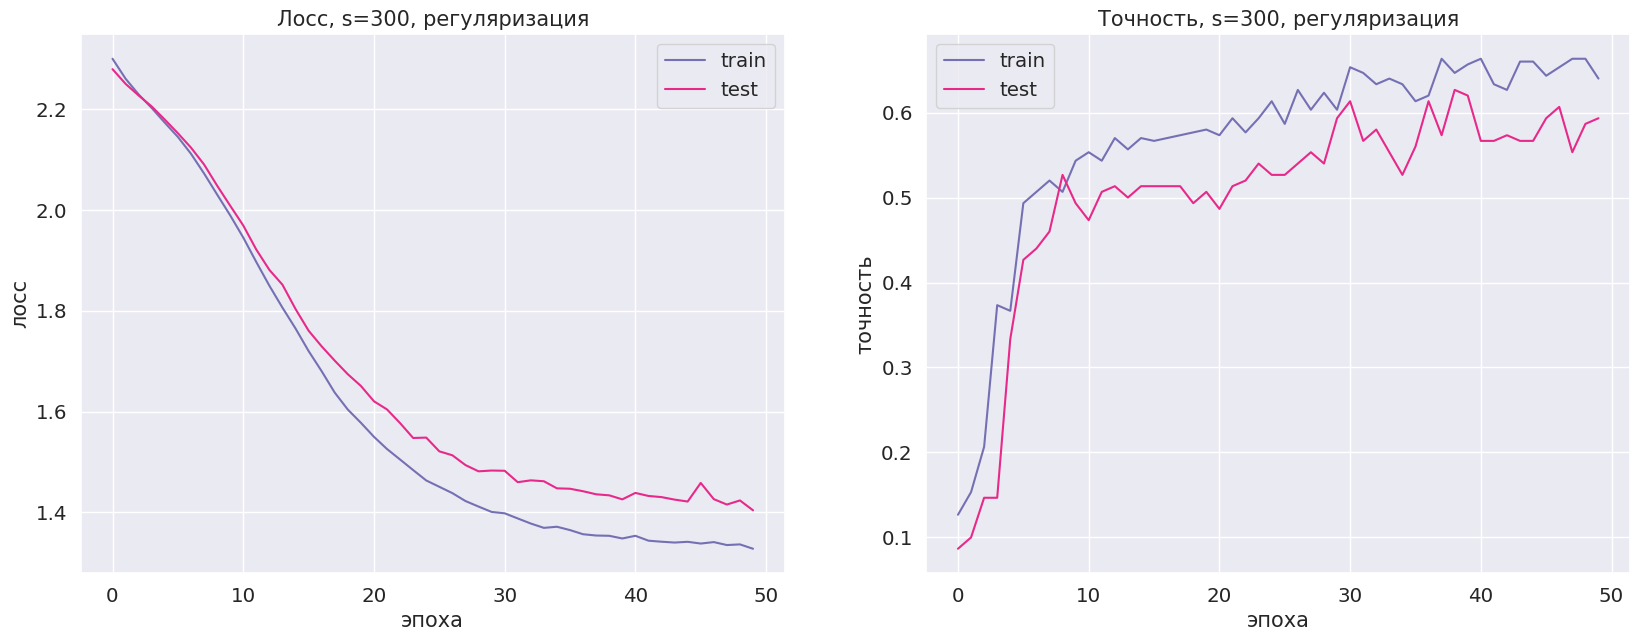

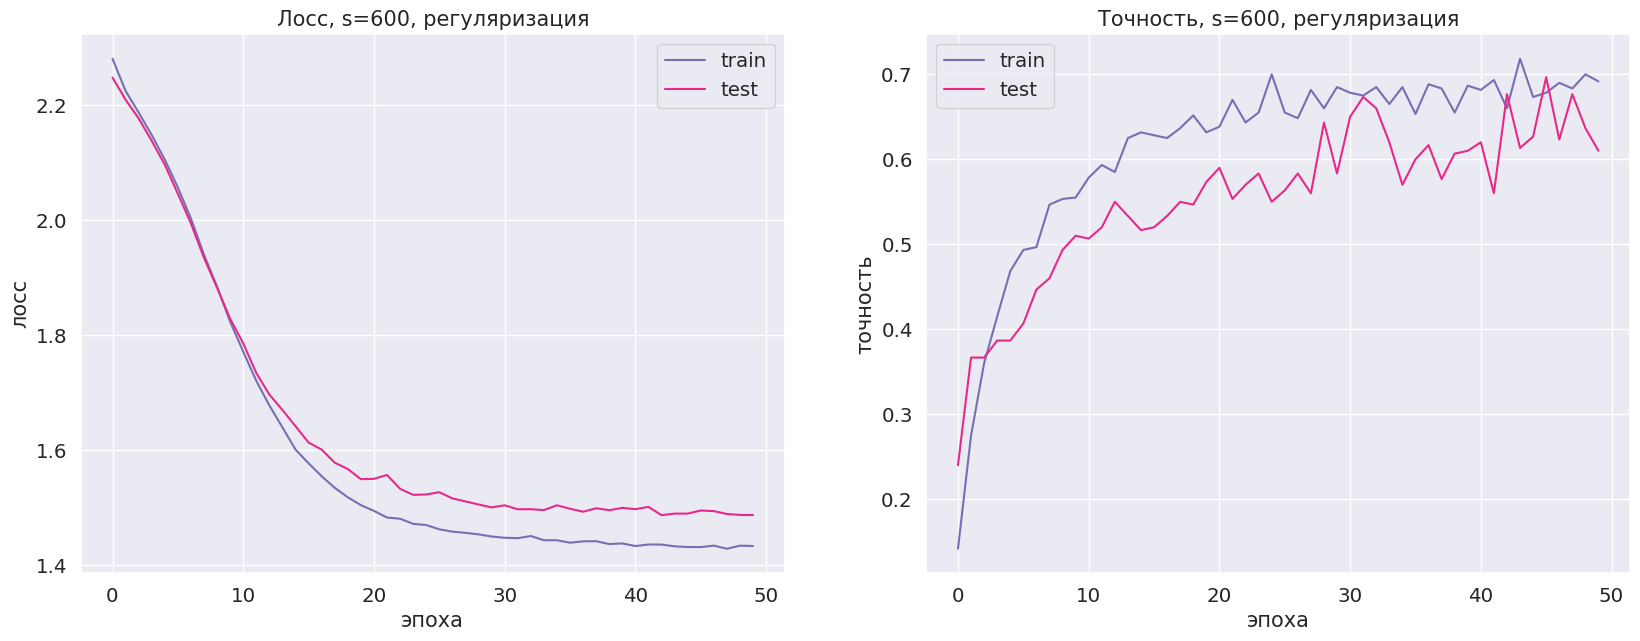

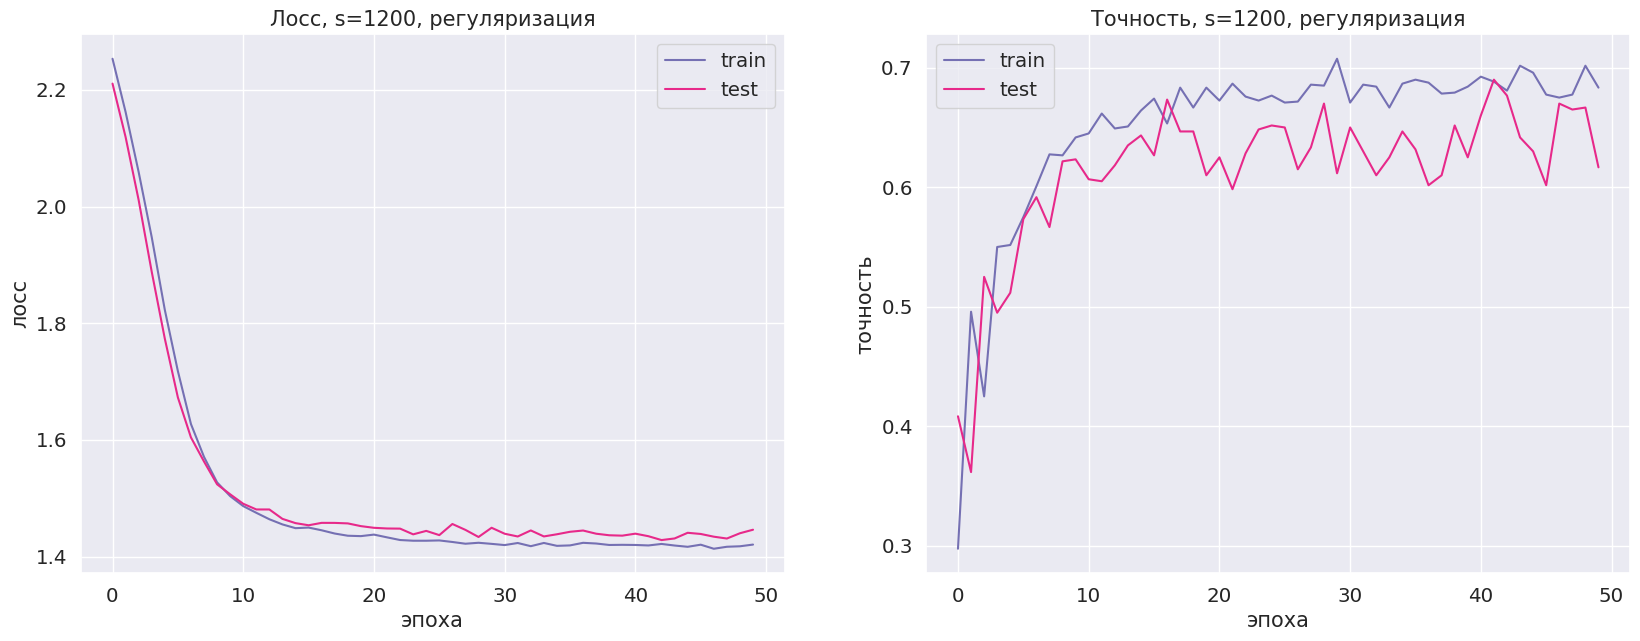

In [18]:
for size in train_sizes:
  fig = plt.figure(figsize=(20, 7))

  plt.subplot(1,2,1)
  plt.title(f'Лосс, s={size}, регуляризация', fontsize=15)
  plt.plot(history[size]['loss']['train'], label='train')
  plt.plot(history[size]['loss']['test'], label='test')
  plt.ylabel('лосс', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()

  plt.subplot(1,2,2)
  plt.title(f'Точность, s={size}, регуляризация', fontsize=15)
  plt.plot(history[size]['acc']['train'], label='train')
  plt.plot(history[size]['acc']['test'], label='test')
  plt.ylabel('точность', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()
  plt.show()

In [19]:
train_sizes = [300, 600, 1200]
batch_size = 32
epochs = 50
history = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for size in tqdm(train_sizes, desc=f'size'):
    model = create_model_do().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_subset = get_subset(train_set, size)
    test_subset = get_subset(test_set, size // 2)

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(epochs), desc=f"size={size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history[size]['loss']['train'].append(epoch_loss)
        history[size]['acc']['train'].append(epoch_accuracy)
        history[size]['loss']['test'].append(avg_loss)
        history[size]['acc']['test'].append(avg_accuracy)

size:   0%|          | 0/3 [00:00<?, ?it/s]

size=300:   0%|          | 0/50 [00:00<?, ?it/s]

size=600:   0%|          | 0/50 [00:00<?, ?it/s]

size=1200:   0%|          | 0/50 [00:00<?, ?it/s]

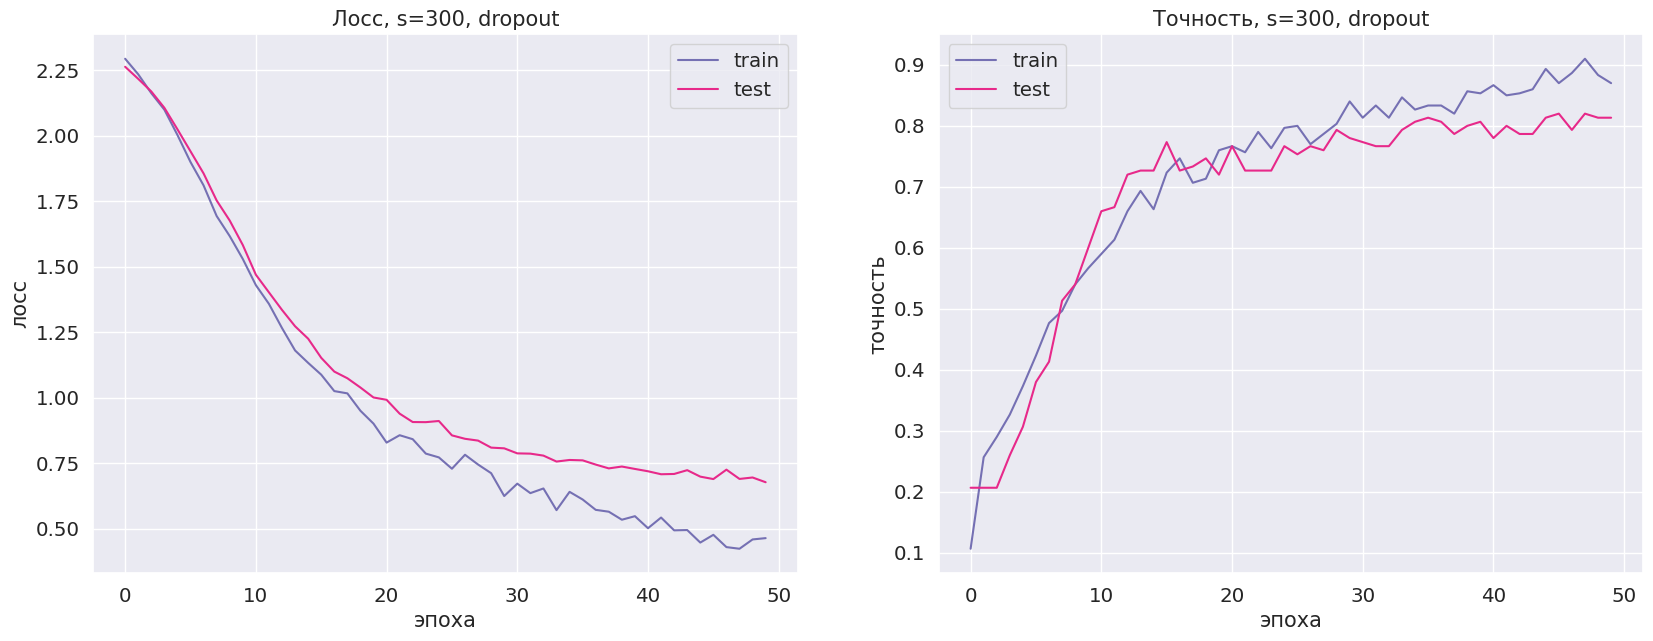

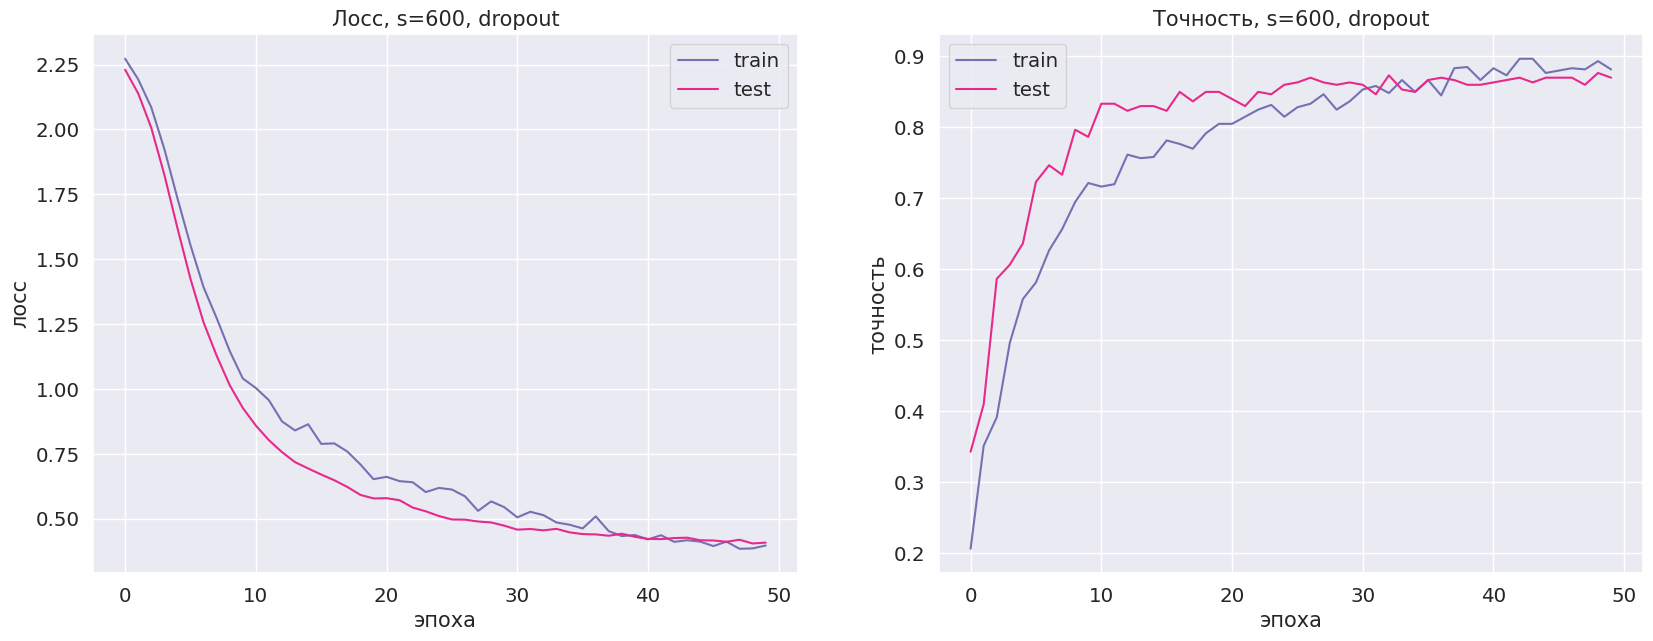

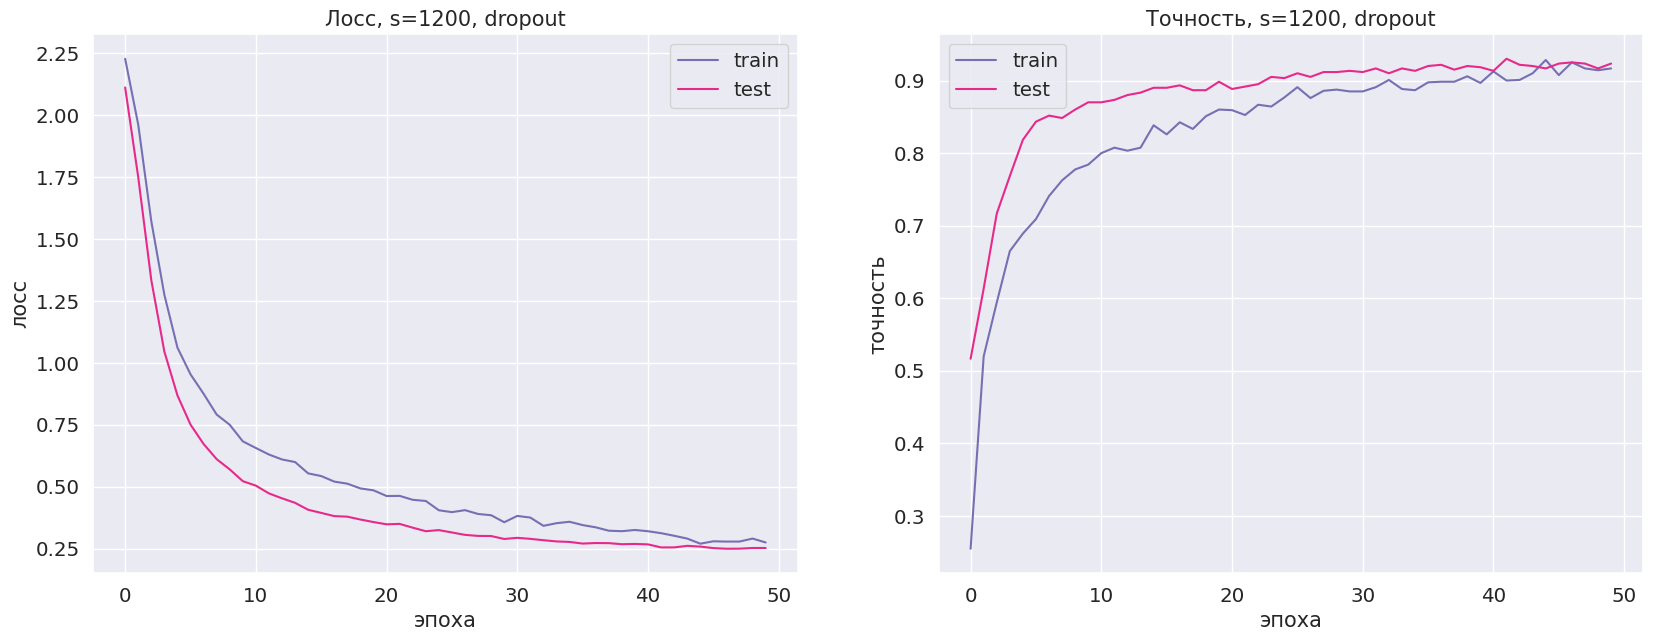

In [20]:
for size in train_sizes:
  fig = plt.figure(figsize=(20, 7))

  plt.subplot(1,2,1)
  plt.title(f'Лосс, s={size}, dropout', fontsize=15)
  plt.plot(history[size]['loss']['train'], label='train')
  plt.plot(history[size]['loss']['test'], label='test')
  plt.ylabel('лосс', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()

  plt.subplot(1,2,2)
  plt.title(f'Точность, s={size}, dropout', fontsize=15)
  plt.plot(history[size]['acc']['train'], label='train')
  plt.plot(history[size]['acc']['test'], label='test')
  plt.ylabel('точность', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()
  plt.show()

In [21]:
train_sizes = [300, 600, 1200]
batch_size = 32
epochs = 50
history = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for size in tqdm(train_sizes, desc=f'size'):
    model = create_model_do().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=0.1)
    criterion = nn.CrossEntropyLoss(reduction='mean')

    train_subset = get_subset(train_set, size)
    test_subset = get_subset(test_set, size // 2)

    train_loader = torch.utils.data.DataLoader(dataset=train_subset,
                                               batch_size=batch_size,
                                               shuffle=True, num_workers=N_JOBS)
    test_loader = torch.utils.data.DataLoader(dataset=test_subset,
                                              batch_size=batch_size,
                                              shuffle=False, num_workers=N_JOBS)

    for epoch in tqdm(range(epochs), desc=f"size={size}", leave=False):
        epoch_loss, epoch_accuracy = train_one_epoch(model=model,
                                                     loader=train_loader,
                                                     optimizer=optimizer,
                                                     device=device,
                                                     criterion=criterion)

        avg_loss, avg_accuracy = evaluate(model=model,
                                          loader=test_loader,
                                          device=device,
                                          criterion=criterion)

        history[size]['loss']['train'].append(epoch_loss)
        history[size]['acc']['train'].append(epoch_accuracy)
        history[size]['loss']['test'].append(avg_loss)
        history[size]['acc']['test'].append(avg_accuracy)

size:   0%|          | 0/3 [00:00<?, ?it/s]

size=300:   0%|          | 0/50 [00:00<?, ?it/s]

size=600:   0%|          | 0/50 [00:00<?, ?it/s]

size=1200:   0%|          | 0/50 [00:00<?, ?it/s]

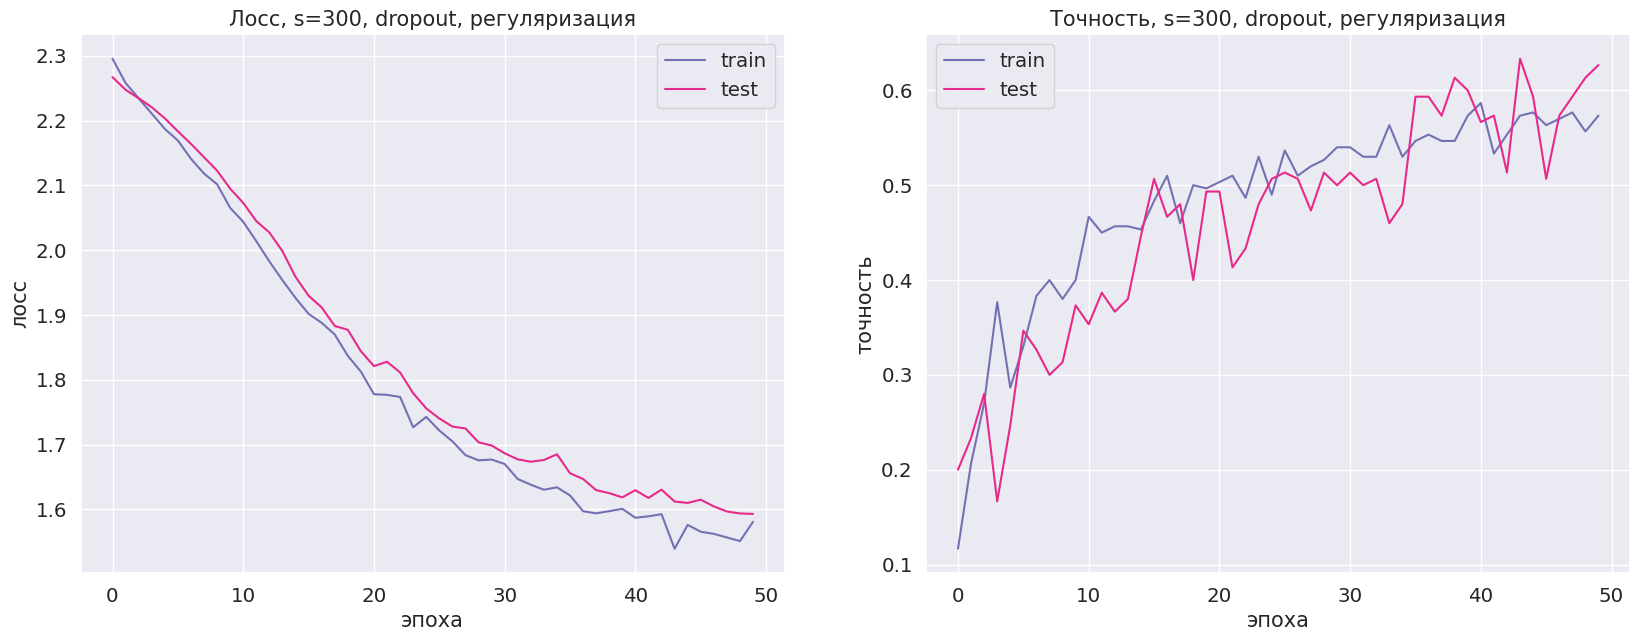

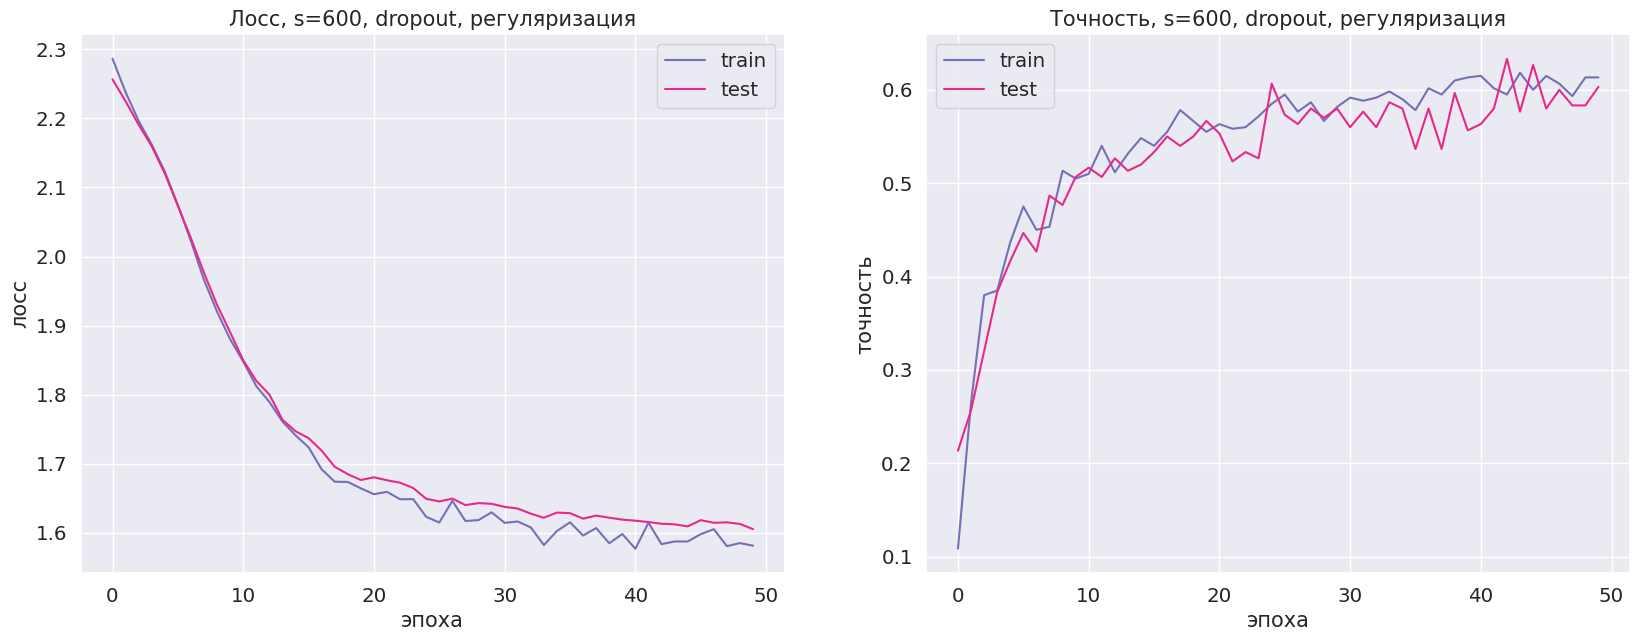

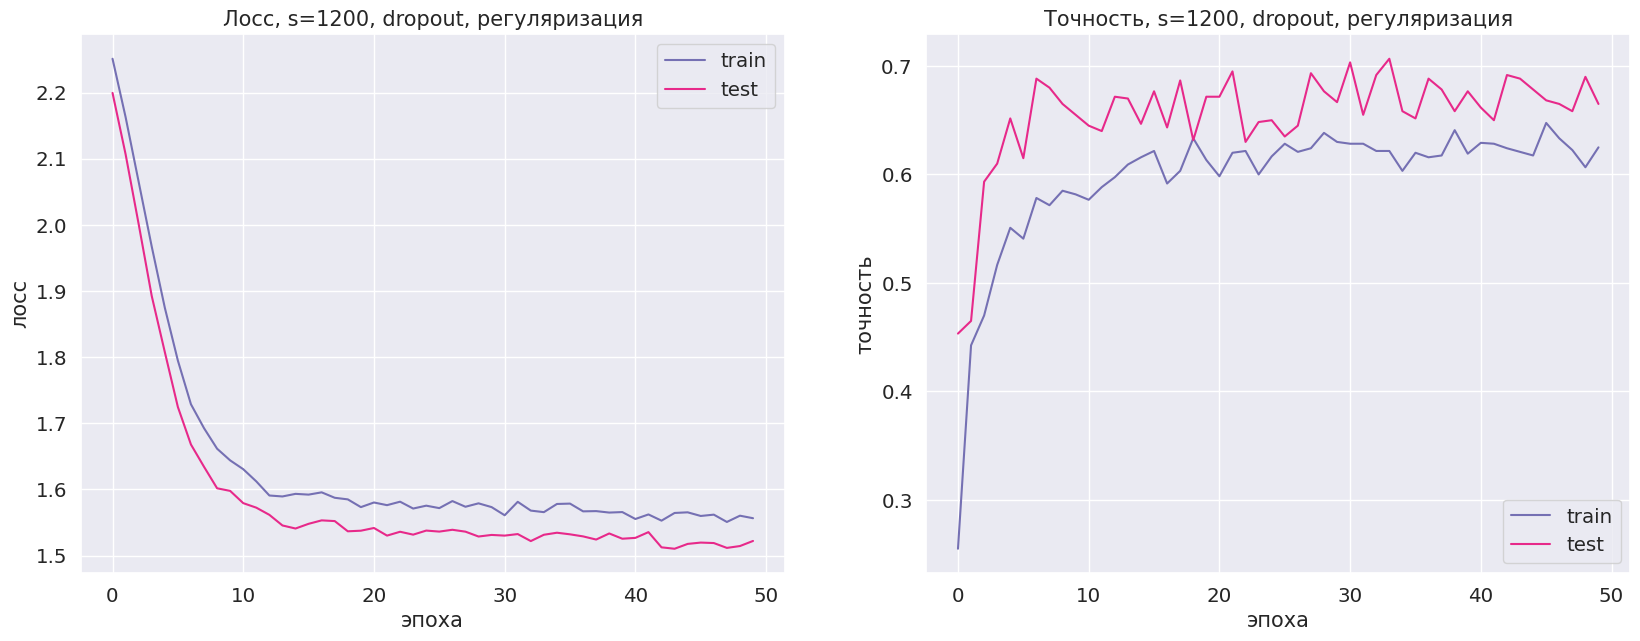

In [23]:
for size in train_sizes:
  fig = plt.figure(figsize=(20, 7))

  plt.subplot(1,2,1)
  plt.title(f'Лосс, s={size}, dropout, регуляризация', fontsize=15)
  plt.plot(history[size]['loss']['train'], label='train')
  plt.plot(history[size]['loss']['test'], label='test')
  plt.ylabel('лосс', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()

  plt.subplot(1,2,2)
  plt.title(f'Точность, s={size}, dropout, регуляризация', fontsize=15)
  plt.plot(history[size]['acc']['train'], label='train')
  plt.plot(history[size]['acc']['test'], label='test')
  plt.ylabel('точность', fontsize=15)
  plt.xlabel('эпоха', fontsize=15)
  plt.legend()
  plt.show()

Сделайте выводы об эффекте переобучения и методах регуляризации.

**Выводы:** Видим, что l2 регуляризация даёт больше смещение, нужно юрат ьменьше гиперпараметр и быть аккуратнее. Интересно сравнить обычную модель и модель с dropout. Видим, что при size=1200 в первому случае по лоссу можно увидеть переобучение, train же остался чуть меньше 0.5. При использовании dropout для того же size test даже меньше, чем test, и около значения 0.25. До переобучения за 50 эпох не дошло, да и видно, что метод предостерегает от него

---
### Задача 2.

**При решении этой задачи запрещено использовать ИИ-инструменты во всех пунктах задачи.**

В этой части задания вам предстоит реализовать с нуля упрощённую версию библиотеки **PyTorch**, чтобы на практике понять, как работают вычислительные графы и автоматическое дифференцирование. Для вас подготовлен шаблон минимального фреймворка, включающего класс `Tensor` с поддержкой вычислительного графа, базовые операции над тензорами, а также основные элементы нейросетей — слои `Linear`, `ReLU`, контейнер `Sequential`, функции потерь и оптимизатор `SGD`. В местах с пометкой `<ВАШ КОД ЗДЕСЬ>` вам нужно самостоятельно реализовать недостающие части кода, отвечающие за прямое и обратное распространение сигналов. Затем вы проверите свою реализацию, обучив небольшую нейросеть на синтетических данных.

В отличие от задачи на курсе **«Введение в анализ данных»**, где вы реализовывали обучение нейросети «вручную» в стиле `scikit-learn` — выписывали производные и обновляли параметры напрямую, — теперь вы перейдёте на другой уровень абстракции. В этом упражнении основное внимание уделено механизму **автоматического дифференцирования**: вы создадите систему, которая сама строит вычислительный граф и вычисляет градиенты для любых операций. Это позволит увидеть, как современные фреймворки вроде PyTorch (или TensorFlow) автоматизируют то, что раньше приходилось делать вручную.

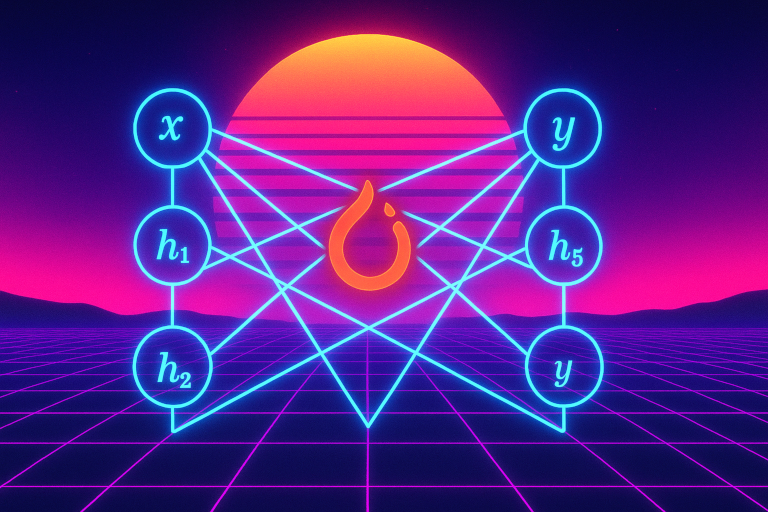

**1.** **Реализация `Tensor`**

Реализуйте класс `Tensor`. Пишите код только в специально помеченных местах, ориентируйтесь на комментарии. Для вычисления производных функций воспользуйтесь матричным дифференцированием.

In [19]:
a = np.array([1, 1, 1])
b = np.array([[1, 2, 3], [4, 5, 6]])
print(a * b)
len(a.shape)

[[1 2 3]
 [4 5 6]]


1

In [4]:
# При реализации класса запрещено использовать ИИ-инструменты

class Tensor:
    """
    Упрощённая версия PyTorch Tensor с поддержкой вычислительного графа
    и автоматического дифференцирования.

    Атрибуты:
        data (np.ndarray): Значения тензора.
        requires_grad (bool): Нужно ли вычислять градиенты.
        grad (Optional[np.ndarray]): Текущее значение градиента.
        _backward (Callable): Функция обратного прохода для текущей операции.
        _prev (Set[Tensor]): Вершины, участвующие в создании текущего тензора.
        _op (str): Название операции (для отладки и визуализации).
    """

    def __init__(
        self,
        data: Union[np.ndarray, List, float],
        requires_grad: bool = False,
        _children: Tuple['Tensor', ...] = (),
        _op: str = ''
    ):
        """
        Инициализирует объект Tensor.

        Args:
            data (Union[np.ndarray, List, float]): Входные данные для создания тензора.
            requires_grad (bool): Если True, для этого тензора будут вычисляться градиенты.
            _children (Tuple['Tensor', ...]): Родительские тензоры в графе вычислений.
            _op (str): Название операции, создавшей тензор.
        """
        self.data = np.array(data, dtype=np.float32)
        self.requires_grad = requires_grad
        self.grad = None

        # В PyTorch есть объект `grad_fn`, который хранит и функцию для обратного прохода,
        # и ссылки на следующие узлы графа. Для домашнего задания мы слегка упрощаем эту логику:
        # `_backward` — это только функция, а `_prev` — это ссылки на предыдущие узлы (операнды).
        self._backward = lambda: None
        self._prev = set(_children)

        self._op = _op

    def __add_grad(self, grad: np.ndarray, current_grad: Optional[np.ndarray]) -> np.ndarray:

        """
        Аккумулирует (суммирует) градиенты.

        Если тензор используется в нескольких операциях, его градиент будет суммой
        градиентов, пришедших от каждой из этих операций.

        Args:
            grad (np.ndarray): Новый градиент, который нужно добавить.
            current_grad (Optional[np.ndarray]): Текущий накопленный градиент (может быть None).

        Returns:
            np.ndarray: Обновлённый градиент.
        """

        if current_grad is None:
            # Градиента еще не было, инициализируем его
            return grad
        else:
            # Иначе используем накопление градиента
            return current_grad + grad

    def __add__(self, other: Union['Tensor', float, np.ndarray]) -> 'Tensor':
        """
        Выполняет поэлементное сложение.

        Args:
            other (Union['Tensor', float, np.ndarray]): Второй операнд для сложения.

        Returns:
            'Tensor': Новый тензор, являющийся результатом сложения.
        """
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data + other.data,
            requires_grad=self.requires_grad or other.requires_grad,
            _children=(self, other),
            _op='+'
        )

        def _backward():
            """Распространяет градиент на операнды с учётом broadcasting'а."""

            # Обрабатываем одну ветку графа вычислений
            if self.requires_grad:
                grad = out.grad
                # Производная суммы по каждому из слагаемых равна 1. Поэтому градиент,
                # пришедший к `out`, просто передаётся дальше на `self` и `other`.
                # Обращайте внимание на размерности тензоров с учётом broadcasting'а.
                # Подумайте, как должна работать операция в случаях размерностей
                # 1. self.data.shape = (3,) и other.data.shape = (2, 3)
                # 2. self.data.shape = (1, 3) и other.data.shape = (2, 3)
                # 3. self.data.shape = (2, 3) и other.data.shape = (2, 3)
                # 4. Другие подобные случаи.
                # В частности: какая размерность self.grad, по каким осям суммировать?
                if self.data.shape != other.data.shape:
                    # Нужно учесть все правила: если одно из измерений 1, то оно растягивается. Измерения сверяются с конца,
                    # тензоры могут быть многомерные. Здесб разобраны только случаи как выше
                    grad.sum(dim=0)
                self.grad = self.__add_grad(grad, self.grad)

            # Обрабатываем другую ветку графа вычислений
            if other.requires_grad:
                grad = out.grad
                if self.data.shape != other.data.shape:
                    grad.sum(dim=0)
                other.grad = other.__add_grad(grad, other.grad)
        out._backward = _backward
        return out

    def __matmul__(self, other: 'Tensor') -> 'Tensor':
        """Матричное умножение"""
        
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data @ other.data,
            requires_grad=self.requires_grad or other.requires_grad,
            _children=(self, other),
            _op='@'
        )

        def _backward():
            # Подумайте, какие здесь должны быть преобразования градиентов.
            # При затруднении обратитесь к ноутбукам с занятия НА САЙТЕ.
            if self.requires_grad:
                grad = out.grad @ other.data.T
                self.grad = self.__add_grad(grad, self.grad)
            if other.requires_grad:
                grad = self.data.T @ out.grad
                self.grad = self.__add_grad(grad, self.grad)

        out._backward = _backward
        return out

    def __neg__(self) -> 'Tensor':
        """Унарный минус"""
        
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(-self.data, requires_grad=self.requires_grad, _children=(self,), _op='neg')
    
        def _backward():
            if self.requires_grad:
                grad = -out.grad
                self.grad = self.__add_grad(grad, self.grad)

        out._backward = _backward
        return out

    def __sub__(self, other: Union['Tensor', float, np.ndarray]) -> 'Tensor':
        """Вычитание"""

        other = other if isinstance(other, Tensor) else Tensor(other)
        return self + (-other)

    def __mul__(self, other: Union['Tensor', float, np.ndarray]) -> 'Tensor':
        """Покомпонентное умножение"""

        out = Tensor(self.data * other.data, _op='*')

        <ВАШ КОД ЗДЕСЬ>
        return <ВАШ КОД ЗДЕСЬ>

    def __truediv__(self, other: Union['Tensor', float]) -> 'Tensor':
        """Покомпонентное деление"""

        <ВАШ КОД ЗДЕСЬ>
        return <ВАШ КОД ЗДЕСЬ>

    def __pow__(self, power: float) -> 'Tensor':
        """Возведение в степень с сохранением графа"""

        out = Tensor(<ВАШ КОД ЗДЕСЬ>, _op=f'**{power}')

        <ВАШ КОД ЗДЕСЬ>
        return <ВАШ КОД ЗДЕСЬ>

    def relu(self) -> 'Tensor':
        """Применяет ReLU к каждому элементу тензора"""
        
        out = Tensor(<ВАШ КОД ЗДЕСЬ>, _op='ReLU')

        <ВАШ КОД ЗДЕСЬ>
        return <ВАШ КОД ЗДЕСЬ>

    def exp(self) -> 'Tensor':
        """Поэлементное экспоненцирование"""

        out = Tensor(<ВАШ КОД ЗДЕСЬ>, _op='exp')

        <ВАШ КОД ЗДЕСЬ>
        return out


    def log(self) -> 'Tensor':
        """Поэлементный натуральный логарифм"""

        out = Tensor(<ВАШ КОД ЗДЕСЬ>, _op='log')

        <ВАШ КОД ЗДЕСЬ>
        return out

    def sum(
        self,
        axis: Optional[Union[int, Tuple[int, ...]]] = None,
        keepdims: bool = False
    ) -> 'Tensor':
        """
        Суммирует элементы тензора по заданной оси или по всему тензору.

        Args:
            axis (Optional[Union[int, Tuple[int, ...]]]): Ось или оси для суммирования.
            keepdims (bool): Сохранять ли размерность оси, по которой идет суммирование.

        Returns:
            'Tensor': Тензор с результатом суммирования.
        """

        out = Tensor(
            self.data.sum(axis=axis, keepdims=keepdims),
            requires_grad=self.requires_grad,
            _children=(self,),
            _op='sum'
        )

        def _backward():
            if self.requires_grad:
                grad = out.grad


                # При суммировании градиент нужно "раскопировать" по тем измерениям,
                # которые были схлопнуты. Это обратная операция к суммированию.
                if axis is not None:
                    if not isinstance(axis, tuple):
                        axes = (axis,)
                    else:
                        axes = axis

                    # Добавляем оси, если keepdims=False
                    # Дублируем значения по суммированным осям
                    <ВАШ КОД ЗДЕСЬ>

                else:
                    grad = <ВАШ КОД ЗДЕСЬ>

                self.grad = self.__add_grad(grad, self.grad)

        out._backward = _backward
        return out


    def backward(self) -> None:
        """
        Запускает вычисление градиентов по построенному графу операций.

        Реализовано через **топологический обход графа (по сути, обход дерева в ширину)**:
        1. Рекурсивно строим список всех узлов, участвующих в вычислениях.
        2. Обходим их в обратном порядке (от результата к листьям).
        3. На каждом шаге вызываем сохранённую `_backward()` для локального узла.

        Примечание:
            Работает только для скалярных выходов (например, loss).
        """

        topo = []
        visited = set()

        def build_topo(v: 'Tensor'):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        # 1. Строим порядок вычислений
        build_topo(self)

        # 2. Инициализируем градиент для конечного узла (обычно loss)
        self.grad = np.ones_like(self.data)

        # 3. Обходим граф в обратном порядке (от выхода к входам)
        for node in reversed(topo):
            node._backward()

    def zero_grad(self) -> None:
        """Зануляет градиенты тензора"""

        self.grad = None

    def __repr__(self) -> str:
        return f"Tensor({self.data}, requires_grad={self.requires_grad})"

SyntaxError: invalid syntax (2438237788.py, line 102)

Теперь протестируем написанный `Tensor`. Код должен пройти все тесты.

In [2]:
"""Базовые тесты"""


def test_add_backward(Tensor):
    a = Tensor([1.0, 2.0, 3.0], requires_grad=True)
    b = Tensor([4.0, 5.0, 6.0], requires_grad=True)
    c = a + b
    loss = c.sum()
    loss.backward()

    passed1 = np.allclose(a.grad, np.ones_like(a.data))
    passed2 = np.allclose(b.grad, np.ones_like(b.data))
    return passed1 and passed2


def test_mul_backward(Tensor):
    a = Tensor([2.0, 3.0], requires_grad=True)
    b = Tensor([4.0, 5.0], requires_grad=True)
    c = (a * b).sum()
    c.backward()

    passed1 = np.allclose(a.grad, b.data)
    passed2 = np.allclose(b.grad, a.data)
    return passed1 and passed2


def test_matmul_backward(Tensor):
    a = Tensor([[1.0, 2.0]], requires_grad=True)  # [1,2]
    b = Tensor([[3.0], [4.0]], requires_grad=True)  # [2,1]
    c = (a @ b).sum()
    c.backward()

    # dc/da = b^T = [[3,4]]
    # dc/db = a^T = [[1],[2]]
    passed1 = np.allclose(a.grad, b.data.T)
    passed2 = np.allclose(b.grad, a.data.T)
    return passed1 and passed2


def test_relu_backward(Tensor):
    a = Tensor([-1.0, 0.0, 2.0], requires_grad=True)
    b = a.relu().sum()
    b.backward()

    passed1 = np.allclose(a.grad, [0.0, 0.0, 1.0])
    return passed1


def test_pow_backward(Tensor):
    a = Tensor([2.0, 3.0], requires_grad=True)
    b = (a**2).sum()
    b.backward()

    passed1 = np.allclose(a.grad, 2 * a.data)
    return passed1


def test_base(Tensor):
    tests = {
        "Базовые тесты": {
            "add + backward": test_add_backward,
            "mul + backward": test_mul_backward,
            "matmul + backward": test_matmul_backward,
            "ReLU + backward": test_relu_backward,
            "pow + backward": test_pow_backward,
        }
    }

    count_all_tests = 0
    count_passed_tests = 0

    for test_group in tests:
        count_all_tests_group = 0
        count_passed_tests_group = 0

        delim_len = (30 - len(test_group)) // 2
        print(delim_len * "=", test_group, delim_len * "=")

        for test_name, test in tests[test_group].items():
            count_all_tests_group += 1
            try:
                if test(Tensor):
                    count_passed_tests_group += 1
                    print(f"✅ {test_name} пройден")
                else:
                    print(f"❌ {test_name} не пройден")
            except Exception as e:
                print(f"❌ {test_name} не пройден с ошибкой:\n{e}")

        count_all_tests += count_all_tests_group
        count_passed_tests += count_passed_tests_group

        print(f"Пройдено тестов: {count_passed_tests_group}/{count_all_tests_group}\n")

    print(f"Всего пройдено тестов: {count_passed_tests}/{count_all_tests}\n")

In [3]:
test_base(Tensor)

NameError: name 'Tensor' is not defined

Шмякулёк...

#### Визуализация графа
Посмотрим на граф вычислений. Он строится автоматически при выполнении математических операций над тензорами.

Код для визуализации графа уже написан за вас.

In [ ]:
def get_graph(tensor: Tensor) -> Digraph:
    """
    Создаёт объект Graphviz для визуализации вычислительного графа Tensor.

    Args:
        tensor (Tensor): конечный узел (например, loss)
    Returns:
        graphviz.Digraph: объект графа для визуализации
    """

    dot = Digraph(format="png", graph_attr={"rankdir": "LR"})
    visited = set()

    def add_nodes(v):
        if v not in visited:
            visited.add(v)
            # Подпись узла: операция и форма тензора
            node_label = f"{v._op or 'leaf'}, shape={v.data.shape}"
            dot.node(
                str(id(v)),
                node_label,
                shape="record",
                color="lightblue",
                style="filled",
            )

            # Добавляем рёбра к предкам
            for child in v._prev:
                add_nodes(child)
                dot.edge(str(id(child)), str(id(v)))

    add_nodes(tensor)
    return dot


def show_graph(tensor):
    dot = get_graph(tensor)
    dot.render("/tmp/graph", format="png")
    return Image("/tmp/graph.png")

Создадим тензор, проделаем простые вычисления.

In [ ]:
a = Tensor([1, 2, 3], requires_grad=True)
b = a * 2
c = b + 1
d = (c * c).sum()

Отобразим граф.

In [ ]:
show_graph(d)

**Вывод:** ...

**2.** **Реализация модулей для нейросети**

Теперь, когда вы написали код для `Tensor`, можно приступать к написанию простейшей нейросети. Пишите код только в специально помеченных местах, ориентируйтесь на комментарии.

In [ ]:
# При реализации класса запрещено использовать ИИ-инструменты

class Module:
    """
    Базовый класс для всех модулей (слоёв) нейросети.

    Поведение аналогично torch.nn.Module:
    - хранит параметры (тензоры с requires_grad=True);
    - хранит вложенные модули;
    - предоставляет методы для итерации по параметрам и обнуления градиентов.
    """

    def __init__(self) -> None:
        self._parameters = []
        self._modules = []

    def parameters(self) -> List[Tensor]:
        """
        Возвращает список всех параметров (включая параметры вложенных модулей).
        """

        params = []
        for p in self._parameters:
            params.append(p)
        for m in self._modules:
            params.extend(m.parameters())
        return params

    def zero_grad(self) -> None:
        """Обнуляет градиенты всех параметров модуля."""

        for p in self.parameters():
            p.zero_grad()


class Linear(Module):
    """
    Линейный слой (аналог nn.Linear).

    Преобразует вход x размерности [batch, in_features] в [batch, out_features]:
        y = x @ W + b
    """

    def __init__(self, in_features: int, out_features: int) -> None:
        super().__init__()

        # Инициализация весов (малые случайные значения) и нулевых смещений
        self.W = Tensor(<ВАШ КОД ЗДЕСЬ>)
        self.b = Tensor(<ВАШ КОД ЗДЕСЬ>)
        self._parameters = [self.W, self.b]

    def __call__(self, x: Tensor) -> Tensor:
        """Прямое вычисление: линейное преобразование."""

        return <ВАШ КОД ЗДЕСЬ>


class ReLU(Module):
    """Реализация функции активации ReLU"""

    def __call__(self, x: Tensor) -> Tensor:
        """Прямое вычисление ReLU: max(0, x)"""

        return x.relu()


class Sequential(Module):
    """
    Контейнер для последовательного применения слоёв.
    Пример:
        model = Sequential(Linear(4, 8), ReLU(), Linear(8, 1))
    """

    def __init__(self, *layers: Module) -> None:
        super().__init__()
        self.layers = layers
        self._modules = list(layers)

    def __call__(self, x: Tensor) -> Tensor:
        """Прогоняет данные через все слои модели последовательно"""

        for layer in self.layers:
            <ВАШ КОД ЗДЕСЬ>
        return x


class MSELoss(Module):
    """
    Среднеквадратичная ошибка (Mean Squared Error Loss).

    Вычисляет сумму квадратов разностей.
    """

    def __call__(self, pred: Tensor, target: Tensor) -> Tensor:
        """Вычисляет MSE loss"""
        <ВАШ КОД ЗДЕСЬ>


class CrossEntropyLoss(Module):
    """
    Кросс-энтропийная функция потерь для многоклассовой классификации.

    Примечание:
        target — массив меток классов (индексы).
    """
    def __call__(self, logits: Tensor, target: np.ndarray) -> Tensor:
        """
        Args:
            logits (Tensor): Выход модели [batch, num_classes]
            target (np.ndarray): Метки классов [batch]
        Returns:
            Tensor: Скаляр — значение функции потерь
        """

        n_samples, n_classes = logits.data.shape

        # 1. Преобразуем target в one-hot Tensor
        <ВАШ КОД ЗДЕСЬ>
        target_one_hot = Tensor(target_one_hot)

        # 2. Применяем softmax
        <ВАШ КОД ЗДЕСЬ>

        # 3. Вычисление кросс-энтропии
        <ВАШ КОД ЗДЕСЬ>
        return loss


class SGD:
    """
    Реализация простейшего оптимизатора - стохастического градиентного спуска (SGD).

    Args:
        params (List[Tensor]): параметры модели
        lr (float): скорость обучения
    """

    def __init__(self, params: List[Tensor], lr: float = 0.01) -> None:
        self.params = params
        self.lr = lr  # фиксированная длина шага обучения

    def step(self):
        """
        Выполняет один шаг обновления параметров
        """
        for p in self.params:
            <ВАШ КОД ЗДЕСЬ>

    def zero_grad(self):
        """Обнуляет градиенты всех параметров"""
        for p in self.params:
            <ВАШ КОД ЗДЕСЬ>


def softmax(x: Tensor) -> Tensor:
    """
    Вычисляет softmax вдоль последней размерности.

    Примечание:
        Для численной стабильности из x вычитается максимум по строке.
    """

    <ВАШ КОД ЗДЕСЬ>

Теперь протестируем написанные модули. Код должен пройти все тесты.

In [ ]:
"""Тесты для линейного модуля и последовательности"""


def test_linear_forward_backward():
    np.random.seed(0)
    x = Tensor(np.random.randn(3, 4), requires_grad=False)
    layer = Linear(4, 2)
    y = layer(x)
    passed1 = y.data.shape == (3, 2)

    loss = y.sum()
    loss.backward()
    # Проверим, что градиенты действительно не None
    passed2 = layer.W.grad is not None and layer.b.grad is not None
    return passed1 and passed2


def test_sequential_forward():
    model = Sequential(Linear(3, 2), ReLU(), Linear(2, 1))
    x = Tensor(np.ones((5, 3)))
    y = model(x)
    passed1 = y.data.shape == (5, 1)
    return passed1


def test_two_layer_mlp_forward():
    np.random.seed(0)
    model = Sequential(Linear(4, 8), ReLU(), Linear(8, 2))
    x = Tensor(np.random.randn(10, 4))
    y = model(x)
    passed1 = y.data.shape == (10, 2)
    return passed1


def test_sequential_three_layers_forward():
    np.random.seed(123)
    model = Sequential(Linear(6, 12), ReLU(), Linear(12, 4), ReLU(), Linear(4, 2))
    x = Tensor(np.random.randn(7, 6))
    y = model(x)
    passed1 = y.data.shape == (7, 2)
    return passed1


""" Тесты для лосса """


def test_mse_loss():
    pred = Tensor([1.0, 2.0, 3.0], requires_grad=True)
    target = Tensor([1.0, 0.0, 2.0])
    loss = MSELoss()(pred, target)
    loss.backward()
    # dL/dpred = 2*(pred - target)
    expected_grad = 2 * (pred.data - target.data)
    passed1 = np.allclose(pred.grad, expected_grad)
    return passed1


def test_cross_entropy_loss():
    np.random.seed(0)
    logits = Tensor(np.random.randn(3, 4), requires_grad=True)
    target = np.array([0, 2, 1])
    loss = CrossEntropyLoss()(logits, target)
    loss.backward()
    passed1 = loss.data > 0
    passed2 = logits.grad is not None
    return passed1 and passed2


def test_modules():
    tests = {
        "Простые модели": {
            "Линейный слой": test_linear_forward_backward,
            "Sequential": test_sequential_forward,
            "Два слоя": test_two_layer_mlp_forward,
            "Три слоя": test_sequential_three_layers_forward,
        },
        "Лосс": {"MSE": test_mse_loss, "Кросс-энтропия": test_cross_entropy_loss},
    }

    count_all_tests = 0
    count_passed_tests = 0

    for test_group in tests:
        count_all_tests_group = 0
        count_passed_tests_group = 0

        delim_len = (30 - len(test_group)) // 2
        print(delim_len * "=", test_group, delim_len * "=")

        for test_name, test in tests[test_group].items():
            count_all_tests_group += 1
            try:
                if test():
                    count_passed_tests_group += 1
                    print(f"✅ {test_name} пройден")
                else:
                    print(f"❌ {test_name} не пройден")
            except Exception as e:
                print(f"❌ {test_name} не пройден с ошибкой:\n{e}")

        count_all_tests += count_all_tests_group
        count_passed_tests += count_passed_tests_group

        print(f"Пройдено тестов: {count_passed_tests_group}/{count_all_tests_group}\n")

    print(f"Всего пройдено тестов: {count_passed_tests}/{count_all_tests}\n")

In [ ]:
test_modules()

Жмякобум...

**3.** **Обучение на датасете MNIST**

Теперь проверим фреймворк на реальной задаче. Обучите двухслойную нейросеть для распознавания рукописных цифр. Будем использовать для этого датасет MNIST, но для упрощения задачи оставим только нули и единицы.

In [ ]:
def load_mnist(
    train_size: int = 6000, target_size: int = 14
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных. По умолчанию 6000.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (torch.Tensor): Тензор с изображениями для обучения.
    train_labels (torch.Tensor): Тензор с метками для обучения.
    test_images (torch.Tensor): Тензор с изображениями для тестирования.
    test_labels (torch.Tensor): Тензор с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_fraction) от исходного набора данных.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

    # Выбираем часть обучающего набора данных
    train_indices = np.random.choice(len(train_dataset), train_size, replace=False)

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = (
        train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    )
    test_images = test_dataset.data.unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images,
        size=(target_size, target_size),
        mode="bilinear",
        align_corners=False,
    )
    test_images = torch.nn.functional.interpolate(
        test_images,
        size=(target_size, target_size),
        mode="bilinear",
        align_corners=False,
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(train_size, -1)
    test_images = test_images.view(len(test_dataset), -1)

    # Получаем метки для выбранных обучающих и всех тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets

    return train_images, train_labels, test_images, test_labels


def filter_data(images, labels):
    """Оставляем классы 0 и 1"""
    mask = labels <= 1
    return images[mask], labels[mask]

In [ ]:
# Загрузим датасет
train_images, train_labels, test_images, test_labels = load_mnist()

# Оставим нули и единицы
train_images, train_labels = filter_data(train_images, train_labels)
test_images, test_labels = filter_data(test_images, test_labels)

Определите двухслойную нейронную сеть. Она должна принимать вектор размерности `(высота_изображения * ширина_изображения, )` и возвращать метку класса.

In [ ]:
model = Sequential(
    # 2 слоя
    ...
)

Зададим критерий (в нашем случае это кросс-энтропия для класификации) и оптимизатор.

In [ ]:
criterion = CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=0.1)

Обычно запускать эпоху на всём датасете затратно по памяти, поэтому напишите простой даталоадер &mdash; генератор батчей.

In [ ]:
def get_batches(X, y, batch_size=64): ...

Наконец, нейросеть можно обучать. Напишите цикл обучения.

In [ ]:
n_epochs = 10  # число эпох

for epoch in range(1, n_epochs + 1):
    total_loss = 0
    for Xb, yb in get_batches(train_images, train_labels):
        Xb = Tensor(Xb)

        ...

        total_loss += loss.data

    print(f"Epoch {epoch}, Loss: {loss.data}")

Теперь можно оценить качество нейросети на тестовой выборке. Оцените качество на тесте.

In [ ]:
out = model(Tensor(test_images))  # forward pass
probs = softmax(...)  # для получения распределения на логитах
y_pred = np.argmax(...)  # выбор самого вероятносго класса

acc = ...  # оценка accuracy
print(f"Test accuracy: {acc:.3f}")

Бубундяка!

**4.** **Сравнение с PyTorch**

Теперь сравним нашу реализацию с реальным PyTorch на той же задаче классификации рукописных цифр.

Определите двухслойную нейронную сеть на PyTorch, **аналогичную той, что реализовали ранее**. Она должна принимать вектор размерности `(высота_изображения * ширина_изображения, )` и возвращать метку класса.

In [ ]:
model = nn.Sequential(...)

Зададим критерий из `torch.nn` и оптимизатор из `torch.optim`.

In [ ]:
criterion = ...
optimizer = ...

Создадим датасет из данных.

In [ ]:
train_dataset = TensorDataset(train_images, train_labels.unsqueeze(1).float())
test_dataset = TensorDataset(test_images, test_labels.unsqueeze(1).float())

Определим даталоадер `torch.utils.data.DataLoader`.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

Наконец, нейросеть можно обучать. Напишите цикл обучения. Не забывайте переводить модель в режим обучения и в режим валидации.

In [ ]:
n_epochs = 10  # число эпох

for epoch in range(1, n_epochs + 1):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        ...
        total_loss += loss.item()
    print(f"Epoch {epoch}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Теперь можно оценить качество нейросети на тестовой выборке. Оцените качество на тесте.

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test accuracy: {acc:.3f}")

**Выводы:** ...

Турлюмба!

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока